In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
akashdeepkuila_bakery_path = kagglehub.dataset_download('akashdeepkuila/bakery')

print('Data source import complete.')


100%|██████████| 214k/214k [00:00<00:00, 58.4MB/s]

Extracting files...
Data source import complete.


In [ ]:
akashdeepkuila_bakery_path

'/root/.cache/kagglehub/datasets/akashdeepkuila/bakery/versions/2'

In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
%matplotlib inline
from wordcloud import WordCloud

import plotly.express as px
import plotly.graph_objects as go
import plotly.figure_factory as ff
from plotly.offline import download_plotlyjs, init_notebook_mode, iplot

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules
import networkx as nx

In [ ]:
# !pip install prophet --quiet

In [ ]:
# df=pd.read_csv('/kaggle/input/bakery/Bakery.csv')
revised_df=pd.read_csv('/content/bakery_sales_revised.csv')

In [ ]:
revised_df.head()

,Transaction,Item,date_time,period_day,weekday_weekend
0,1,Bread,10/30/2016 9:58,morning,weekend
1,2,Scandinavian,10/30/2016 10:05,morning,weekend
2,2,Scandinavian,10/30/2016 10:05,morning,weekend
3,3,Hot chocolate,10/30/2016 10:07,morning,weekend
4,3,Jam,10/30/2016 10:07,morning,weekend


In [ ]:
revised_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20507 entries, 0 to 20506
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Transaction      20507 non-null  int64 
 1   Item             20507 non-null  object
 2   date_time        20507 non-null  object
 3   period_day       20507 non-null  object
 4   weekday_weekend  20507 non-null  object
dtypes: int64(1), object(4)
memory usage: 801.2+ KB


In [ ]:
revised_df.describe()

,Transaction
count,20507.000000
mean,4976.202370
std,2796.203001
min,1.000000
25%,2552.000000
50%,5137.000000
75%,7357.000000
max,9684.000000


In [ ]:
revised_df.isna().sum()

,0
Transaction,0
Item,0
date_time,0
period_day,0
weekday_weekend,0


In [ ]:
revised_df['Item'].nunique()

94

In [ ]:
revised_df['period_day'].value_counts()

,count
period_day,
afternoon,11569
morning,8404
evening,520
night,14


In [ ]:
revised_df[['period_day','weekday_weekend']].value_counts()

period_day  weekday_weekend
afternoon   weekday            7273
morning     weekday            5174
afternoon   weekend            4296
morning     weekend            3230
evening     weekday             356
            weekend             164
night       weekend              10
            weekday               4
Name: count, dtype: int64

In [ ]:
revised_df['Transaction'].nunique()

9465

In [ ]:
revised_df.describe(include=object)

,Item,date_time,period_day,weekday_weekend
count,20507,20507,20507,20507
unique,94,9182,4,2
top,Coffee,2/5/2017 11:58,afternoon,weekday
freq,5471,12,11569,12807


In [ ]:
revised_df['date_time'] = pd.to_datetime(revised_df['date_time'])

In [ ]:
revised_df['Day'] = revised_df['date_time'].dt.day
revised_df['Time'] = revised_df['date_time'].dt.time
revised_df['Year'] = revised_df['date_time'].dt.year
revised_df['Month'] = revised_df['date_time'].dt.month

In [ ]:
revised_df.head()

,Transaction,Item,date_time,period_day,weekday_weekend,Day,Time,Year,Month
0,1,Bread,2016-10-30 09:58:00,morning,weekend,30,09:58:00,2016,10
1,2,Scandinavian,2016-10-30 10:05:00,morning,weekend,30,10:05:00,2016,10
2,2,Scandinavian,2016-10-30 10:05:00,morning,weekend,30,10:05:00,2016,10
3,3,Hot chocolate,2016-10-30 10:07:00,morning,weekend,30,10:07:00,2016,10
4,3,Jam,2016-10-30 10:07:00,morning,weekend,30,10:07:00,2016,10


In [ ]:
itemfrequency = revised_df['Item'].value_counts().sort_values(ascending=False)
itemfrequency=itemfrequency.head(25)

/tmp/ipython-input-1818586093.py:6: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




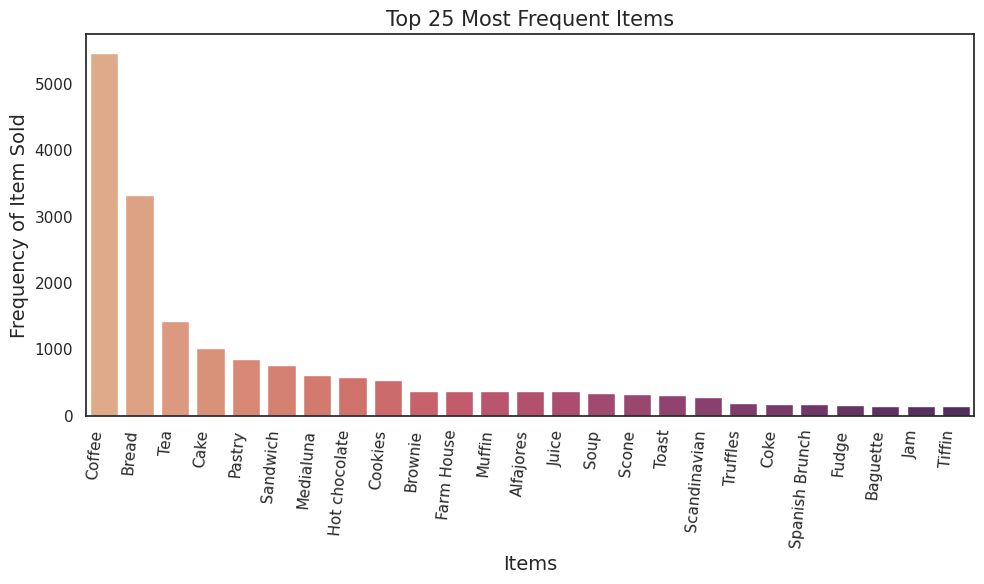

In [ ]:
# Set the style for the plot without grid
sns.set(style="white")

# Create a bar plot
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=itemfrequency.index, y=itemfrequency.values, palette="flare")

# Add title and labels
plt.title('Top 25 Most Frequent Items', fontsize=15)
plt.xlabel('Items', fontsize=14)
plt.ylabel('Frequency of Item Sold', fontsize=14)

# Rotate x-axis labels for better readability
plt.xticks(rotation=85, ha='right')

# Remove grid lines
ax.grid(False)

# Show the plot
plt.tight_layout()
plt.show()

In [ ]:
revised_df.sample(10)

,Transaction,Item,date_time,period_day,weekday_weekend,Day,Time,Year,Month
12054,5967,Tea,2017-02-04 14:54:00,afternoon,weekend,4,14:54:00,2017,2
1161,565,Coffee,2016-11-05 10:44:00,morning,weekend,5,10:44:00,2016,11
9882,4954,Coffee,2017-01-20 08:59:00,morning,weekday,20,08:59:00,2017,1
2413,1172,Muffin,2016-11-12 14:20:00,afternoon,weekend,12,14:20:00,2016,11
9581,4817,Tea,2017-01-17 09:10:00,morning,weekday,17,09:10:00,2017,1
14562,7018,Tea,2017-02-22 14:53:00,afternoon,weekday,22,14:53:00,2017,2
14026,6803,Spanish Brunch,2017-02-18 13:39:00,afternoon,weekend,18,13:39:00,2017,2
5026,2500,Scone,2016-12-03 10:10:00,morning,weekend,3,10:10:00,2016,12
3100,1511,Soup,2016-11-17 12:34:00,afternoon,weekday,17,12:34:00,2016,11
1501,725,Pastry,2016-11-06 15:42:00,afternoon,weekend,6,15:42:00,2016,11


In [ ]:
# import pandas as pd

# Load data
# revised_df = revised_df[revised_df["Item"] != "NONE"]  # Clean missing
# revised_df["date_time"] = pd.to_datetime(revised_df["Date"] + " " + revised_df["Time"])

# # Add time features
# revised_df["Hour"] = revised_df["date_time"].dt.hour
# revised_df["DayOfWeek"] = revised_df["date_time"].dt.day_name()

# # Create DayPart column
# def get_daypart(hour):
#     if 6 <= hour < 12:
#         return "Morning"
#     elif 12 <= hour < 17:
#         return "Afternoon"
#     elif 17 <= hour < 21:
#         return "Evening"
#     else:
#         return "Night"
# revised_df["DayPart"] = revised_df["Hour"].apply(get_daypart)

# # Create Weekday/Weekend
# revised_df["DayType"] = revised_df["DayOfWeek"].apply(lambda x: "Weekend" if x in ["Saturday", "Sunday"] else "Weekday")

# # Group by DayPart and DayType
# summary = revised_df.groupby(["DayPart", "DayType"])["Transaction"].nunique().sort_values(ascending=False)
# print(summary)

In [ ]:
summary = revised_df.groupby(["weekday_weekend", "period_day"])["Transaction"].nunique().sort_values(ascending=False)
print(summary)

weekday_weekend  period_day
weekday          afternoon     3325
                 morning       2648
weekend          afternoon     1764
                 morning       1455
weekday          evening        169
weekend          evening         92
                 night            9
weekday          night            3
Name: Transaction, dtype: int64


In [ ]:
revised_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20507 entries, 0 to 20506
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Transaction      20507 non-null  int64         
 1   Item             20507 non-null  object        
 2   date_time        20507 non-null  datetime64[ns]
 3   period_day       20507 non-null  object        
 4   weekday_weekend  20507 non-null  object        
 5   Day              20507 non-null  int32         
 6   Time             20507 non-null  object        
 7   Year             20507 non-null  int32         
 8   Month            20507 non-null  int32         
dtypes: datetime64[ns](1), int32(3), int64(1), object(4)
memory usage: 1.2+ MB


In [ ]:
revised_df.head()

,Transaction,Item,date_time,period_day,weekday_weekend,Day,Time,Year,Month
0,1,Bread,2016-10-30 09:58:00,morning,weekend,30,09:58:00,2016,10
1,2,Scandinavian,2016-10-30 10:05:00,morning,weekend,30,10:05:00,2016,10
2,2,Scandinavian,2016-10-30 10:05:00,morning,weekend,30,10:05:00,2016,10
3,3,Hot chocolate,2016-10-30 10:07:00,morning,weekend,30,10:07:00,2016,10
4,3,Jam,2016-10-30 10:07:00,morning,weekend,30,10:07:00,2016,10


In [ ]:
basket_size = revised_df.groupby('date_time').size()
basket_distribution = basket_size.value_counts().sort_index()

In [ ]:
basket_distribution

,count
1,3352
2,2803
3,1560
4,871
5,354
6,148
7,51
8,29
9,8
10,1


/tmp/ipython-input-4168438572.py:8: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




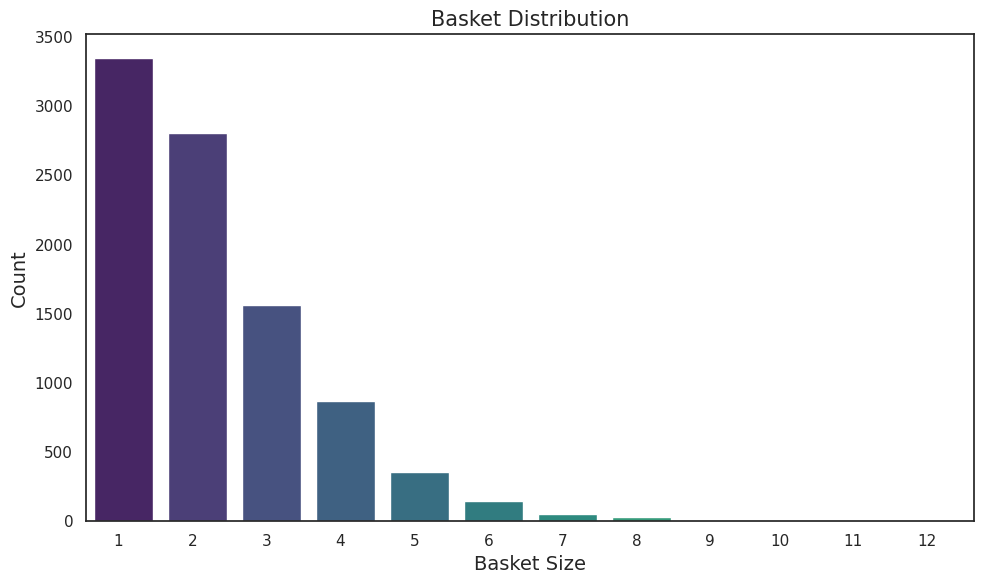

In [ ]:
# basket_distribution.plot(kind='bar')

# Set the style for the plot without grid
sns.set(style="white")

# Create a bar plot
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=basket_distribution.index, y=basket_distribution.values, palette="viridis")

# Add title and labels
plt.title('Basket Distribution', fontsize=15)
plt.xlabel('Basket Size', fontsize=14)
plt.ylabel('Count', fontsize=14)

# Rotate x-axis labels for better readability
plt.xticks( ha='right')

# Remove grid lines
ax.grid(False)

# Show the plot
plt.tight_layout()
plt.show()

# Monthly sales analysis

In [ ]:
revised_df.head()

,Transaction,Item,date_time,period_day,weekday_weekend,Day,Time,Year,Month
0,1,Bread,2016-10-30 09:58:00,morning,weekend,30,09:58:00,2016,10
1,2,Scandinavian,2016-10-30 10:05:00,morning,weekend,30,10:05:00,2016,10
2,2,Scandinavian,2016-10-30 10:05:00,morning,weekend,30,10:05:00,2016,10
3,3,Hot chocolate,2016-10-30 10:07:00,morning,weekend,30,10:07:00,2016,10
4,3,Jam,2016-10-30 10:07:00,morning,weekend,30,10:07:00,2016,10


In [ ]:
Month_name = {
    1: 'January', 2: 'February', 3: 'March', 4: 'April',
    5: 'May', 6: 'June', 7: 'July', 8: 'August',
    9: 'September', 10: 'October', 11: 'November', 12: 'December'
}

revised_df['Month']=revised_df['date_time'].dt.month.map(Month_name)
revised_df.head()

,Transaction,Item,date_time,period_day,weekday_weekend,Day,Time,Year,Month
0,1,Bread,2016-10-30 09:58:00,morning,weekend,30,09:58:00,2016,October
1,2,Scandinavian,2016-10-30 10:05:00,morning,weekend,30,10:05:00,2016,October
2,2,Scandinavian,2016-10-30 10:05:00,morning,weekend,30,10:05:00,2016,October
3,3,Hot chocolate,2016-10-30 10:07:00,morning,weekend,30,10:07:00,2016,October
4,3,Jam,2016-10-30 10:07:00,morning,weekend,30,10:07:00,2016,October


In [ ]:
revised_df['day_name']=revised_df['date_time'].dt.day_name()

In [ ]:
revised_df.head()

,Transaction,Item,date_time,period_day,weekday_weekend,Day,Time,Year,Month,day_name
0,1,Bread,2016-10-30 09:58:00,morning,weekend,30,09:58:00,2016,October,Sunday
1,2,Scandinavian,2016-10-30 10:05:00,morning,weekend,30,10:05:00,2016,October,Sunday
2,2,Scandinavian,2016-10-30 10:05:00,morning,weekend,30,10:05:00,2016,October,Sunday
3,3,Hot chocolate,2016-10-30 10:07:00,morning,weekend,30,10:07:00,2016,October,Sunday
4,3,Jam,2016-10-30 10:07:00,morning,weekend,30,10:07:00,2016,October,Sunday


In [ ]:
grouped_transc=revised_df.groupby('Transaction').agg({
    "Item": ["count",list],
    "date_time": "min",
})
grouped_transc.columns = ['BasketSize', 'ItemsList', 'TransactionTime']
grouped_txn = grouped_transc.reset_index()

In [ ]:
revised_df.describe(include='object')

,Item,period_day,weekday_weekend,Time,Month,day_name
count,20507,20507,20507,20507,20507,20507
unique,94,4,2,687,7,7
top,Coffee,afternoon,weekday,11:06:00,November,Saturday
freq,5471,11569,12807,78,4436,4605


In [ ]:
revised_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20507 entries, 0 to 20506
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Transaction      20507 non-null  int64         
 1   Item             20507 non-null  object        
 2   date_time        20507 non-null  datetime64[ns]
 3   period_day       20507 non-null  object        
 4   weekday_weekend  20507 non-null  object        
 5   Day              20507 non-null  int32         
 6   Time             20507 non-null  object        
 7   Year             20507 non-null  int32         
 8   Month            20507 non-null  object        
 9   day_name         20507 non-null  object        
dtypes: datetime64[ns](1), int32(2), int64(1), object(6)
memory usage: 1.4+ MB


In [ ]:
grouped_txn.describe(include='object')

,ItemsList
count,9465
unique,2893
top,[Bread]
freq,1122


In [ ]:
grouped_txn.describe()

,Transaction,BasketSize,TransactionTime
count,9465.000000,9465.000000,9465
mean,4849.171157,2.166614,2017-01-15 19:44:12.152139264
min,1.000000,1.000000,2016-10-30 09:58:00
25%,2422.000000,1.000000,2016-12-02 08:54:00
50%,4867.000000,2.000000,2017-01-18 10:08:00
75%,7273.000000,3.000000,2017-02-26 15:51:00
max,9684.000000,11.000000,2017-04-09 15:04:00
std,2797.516031,1.301303,NaN


In [ ]:
grouped_txn["BasketSize"].value_counts(normalize=True)*100

,proportion
BasketSize,
1,38.362388
2,30.723719
3,16.143687
4,8.980454
5,3.602747
6,1.426307
7,0.401479
8,0.221870
9,0.073957


In [ ]:
grouped_txn

,Transaction,BasketSize,ItemsList,TransactionTime
0,1,1,[Bread],2016-10-30 09:58:00
1,2,2,"[Scandinavian, Scandinavian]",2016-10-30 10:05:00
2,3,3,"[Hot chocolate, Jam, Cookies]",2016-10-30 10:07:00
3,4,1,[Muffin],2016-10-30 10:08:00
4,5,3,"[Coffee, Pastry, Bread]",2016-10-30 10:13:00
...,...,...,...,...
9460,9680,1,[Bread],2017-04-09 14:24:00
9461,9681,4,"[Truffles, Tea, Spanish Brunch, Christmas common]",2017-04-09 14:30:00
9462,9682,4,"[Muffin, Tacos-Fajita, Coffee, Tea]",2017-04-09 14:32:00
9463,9683,2,"[Coffee, Pastry]",2017-04-09 14:57:00


<Axes: xlabel='BasketSize'>

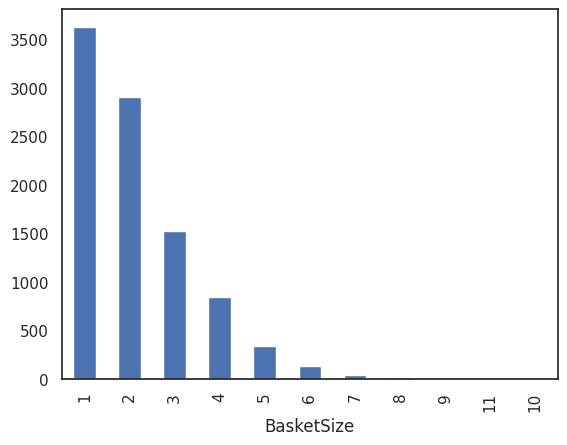

In [ ]:
grouped_txn["BasketSize"].value_counts().plot(kind="bar")

In [ ]:
df_grouped = revised_df.groupby('Transaction').agg({
    'Item': list,
    'Day': 'first',
    'day_name': 'first',
    'period_day': 'first',
    'Year':'first',
    'Month':'first'
}).reset_index()
df_grouped.head()

,Transaction,Item,Day,day_name,period_day,Year,Month
0,1,[Bread],30,Sunday,morning,2016,October
1,2,"[Scandinavian, Scandinavian]",30,Sunday,morning,2016,October
2,3,"[Hot chocolate, Jam, Cookies]",30,Sunday,morning,2016,October
3,4,[Muffin],30,Sunday,morning,2016,October
4,5,"[Coffee, Pastry, Bread]",30,Sunday,morning,2016,October


<Axes: xlabel='Day'>

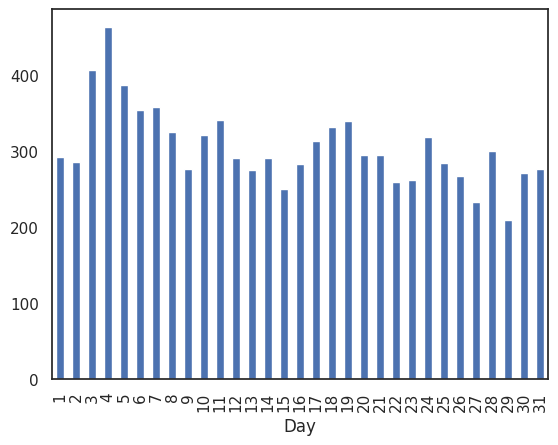

In [ ]:
avg_daily_sales=df_grouped.groupby('Day').size()
avg_daily_sales.plot(kind='bar')

<Axes: >

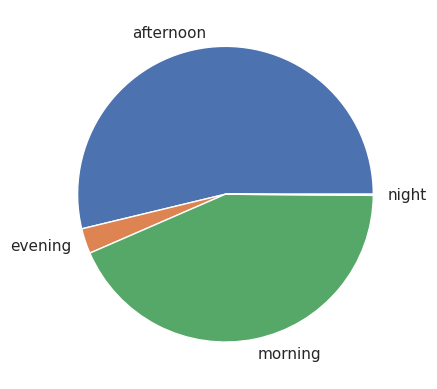

In [ ]:
day_period_sales=df_grouped.groupby('period_day').size()
day_period_sales.plot(kind='pie')

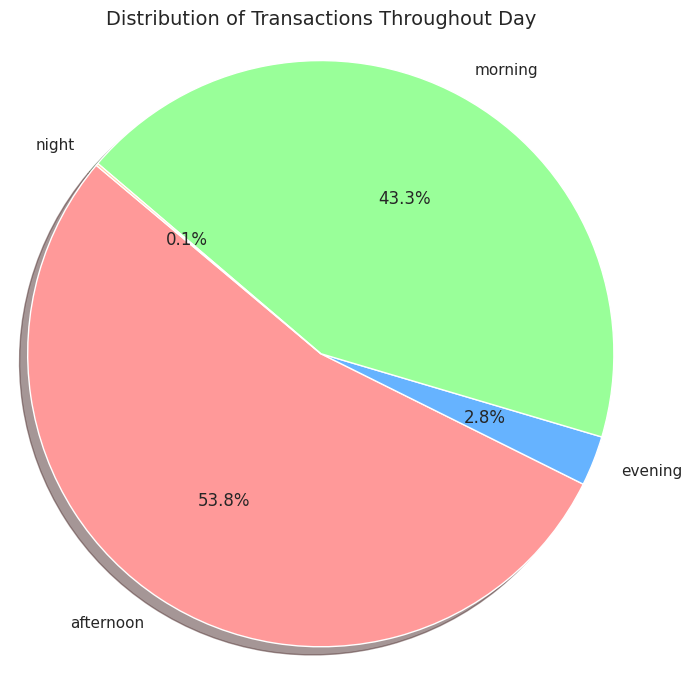

In [ ]:
day_period_sales = df_grouped.groupby('period_day').size()

# Define colors and explode slice for visual clarity
colors = ['#ff9999','#66b3ff','#99ff99','#ffcc99']  # Adjust to match order

# Plot pie chart
plt.figure(figsize=(7, 7))
plt.pie(
    day_period_sales,
    labels=day_period_sales.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    shadow=True
)
plt.title('Distribution of Transactions Throughout Day', fontsize=14)
plt.axis('equal')  # Equal aspect ratio ensures pie is a circle
plt.tight_layout()
plt.show()

<Axes: xlabel='day_name'>

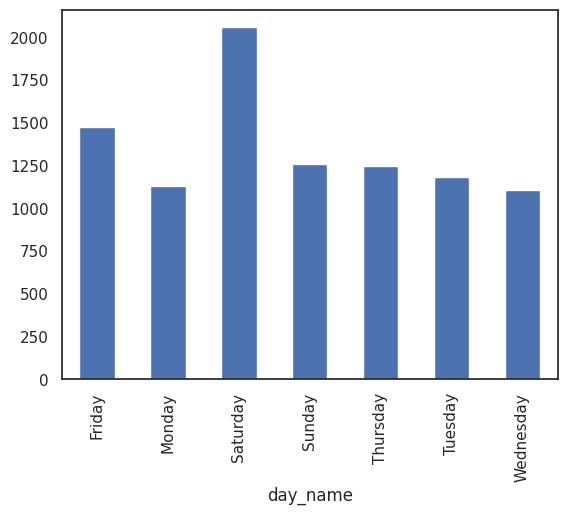

In [ ]:
dayname_period_sales=df_grouped.groupby('day_name').size()
dayname_period_sales.plot(kind='bar')

In [ ]:
revised_df.head()

,Transaction,Item,date_time,period_day,weekday_weekend,Day,Time,Year,Month,day_name
0,1,Bread,2016-10-30 09:58:00,morning,weekend,30,09:58:00,2016,October,Sunday
1,2,Scandinavian,2016-10-30 10:05:00,morning,weekend,30,10:05:00,2016,October,Sunday
2,2,Scandinavian,2016-10-30 10:05:00,morning,weekend,30,10:05:00,2016,October,Sunday
3,3,Hot chocolate,2016-10-30 10:07:00,morning,weekend,30,10:07:00,2016,October,Sunday
4,3,Jam,2016-10-30 10:07:00,morning,weekend,30,10:07:00,2016,October,Sunday


In [ ]:
revised_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20507 entries, 0 to 20506
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Transaction      20507 non-null  int64         
 1   Item             20507 non-null  object        
 2   date_time        20507 non-null  datetime64[ns]
 3   period_day       20507 non-null  object        
 4   weekday_weekend  20507 non-null  object        
 5   Day              20507 non-null  int32         
 6   Time             20507 non-null  object        
 7   Year             20507 non-null  int32         
 8   Month            20507 non-null  object        
 9   day_name         20507 non-null  object        
dtypes: datetime64[ns](1), int32(2), int64(1), object(6)
memory usage: 1.4+ MB


In [ ]:
data=revised_df.copy()

In [ ]:
data.set_index('date_time',inplace=True)

In [ ]:
daily_sales = data.resample('D').size()
daily_sales

,0
date_time,
2016-10-30,170
2016-10-31,199
2016-11-01,150
2016-11-02,164
2016-11-03,189
...,...
2017-04-05,143
2017-04-06,118
2017-04-07,99


In [ ]:
weekly_sales=revised_df.groupby('day_name').size()
sorted_weekly_sales=weekly_sales.reindex(['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])
sorted_weekly_sales

,0
day_name,
Monday,2324
Tuesday,2392
Wednesday,2321
Thursday,2646
Friday,3124
Saturday,4605
Sunday,3095


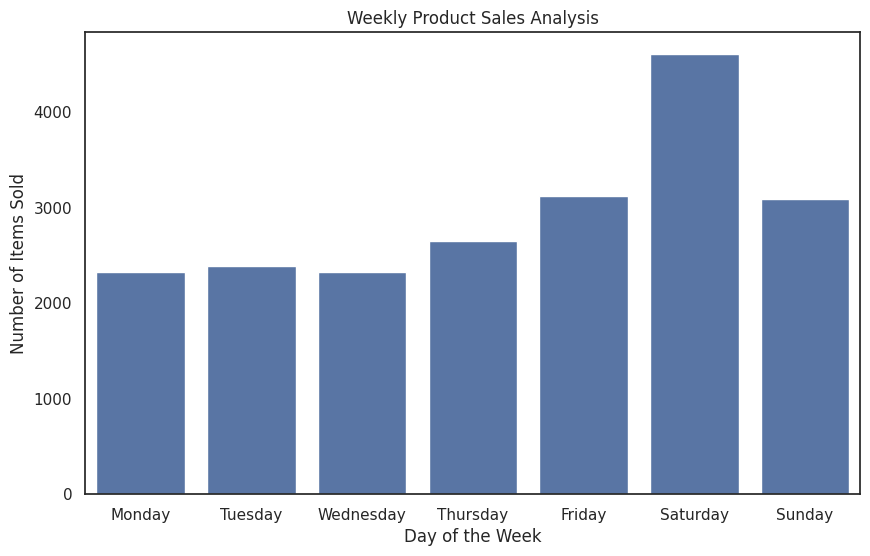

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(x=sorted_weekly_sales.index,y=sorted_weekly_sales.values)
plt.xlabel('Day of the Week')
plt.ylabel('Number of Items Sold')
plt.title('Weekly Product Sales Analysis')
plt.show()

In [ ]:
monthly_sales=revised_df.groupby('Month').size()
# monthly_sales = monthly_sales.reindex(['October','November','December','January','February','March','April'])
monthly_sales

,0
Month,
April,1157
December,3339
February,3906
January,3356
March,3944
November,4436
October,369


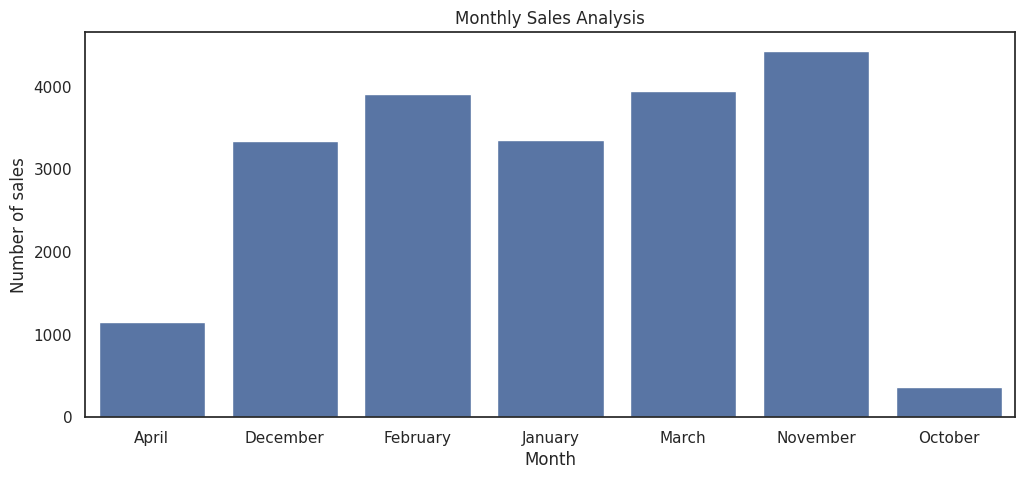

In [ ]:
plt.figure(figsize=(12,5))
# plt.plot(monthly_sales.index,monthly_sales.values)
sns.barplot(x=monthly_sales.index,y=monthly_sales.values)
plt.xlabel('Month')
plt.ylabel('Number of sales')
plt.title('Monthly Sales Analysis')
plt.show()

In [ ]:
monthly_sales.index

Index(['April', 'December', 'February', 'January', 'March', 'November',
       'October'],
      dtype='object', name='Month')

In [ ]:
daily_sales=data.resample('d').size()

In [ ]:
daily_sales

,0
date_time,
2016-10-30,170
2016-10-31,199
2016-11-01,150
2016-11-02,164
2016-11-03,189
...,...
2017-04-05,143
2017-04-06,118
2017-04-07,99


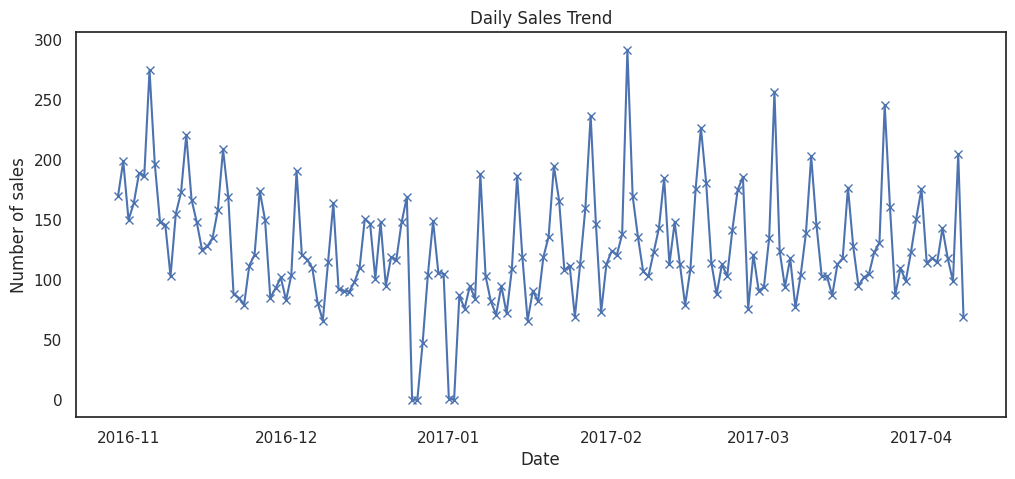

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(daily_sales.index,daily_sales.values,marker='x')
plt.xlabel('Date')
plt.ylabel('Number of sales')
plt.title('Daily Sales Trend')
plt.show()

## Item sales per hour

In [ ]:
data

,Transaction,Item,period_day,weekday_weekend,Day,Time,Year,Month,day_name
date_time,,,,,,,,,
2016-10-30 09:58:00,1,Bread,morning,weekend,30,09:58:00,2016,October,Sunday
2016-10-30 10:05:00,2,Scandinavian,morning,weekend,30,10:05:00,2016,October,Sunday
2016-10-30 10:05:00,2,Scandinavian,morning,weekend,30,10:05:00,2016,October,Sunday
2016-10-30 10:07:00,3,Hot chocolate,morning,weekend,30,10:07:00,2016,October,Sunday
2016-10-30 10:07:00,3,Jam,morning,weekend,30,10:07:00,2016,October,Sunday
...,...,...,...,...,...,...,...,...,...
2017-04-09 14:32:00,9682,Coffee,afternoon,weekend,9,14:32:00,2017,April,Sunday
2017-04-09 14:32:00,9682,Tea,afternoon,weekend,9,14:32:00,2017,April,Sunday
2017-04-09 14:57:00,9683,Coffee,afternoon,weekend,9,14:57:00,2017,April,Sunday


In [ ]:
hourly_data=data.resample('h').size()

In [ ]:
hourly_data

,0
date_time,
2016-10-30 09:00:00,1
2016-10-30 10:00:00,57
2016-10-30 11:00:00,28
2016-10-30 12:00:00,33
2016-10-30 13:00:00,34
...,...
2017-04-09 11:00:00,17
2017-04-09 12:00:00,15
2017-04-09 13:00:00,8


In [ ]:
# plt.figure(figsize=(10,6))
# sns.barplot(x=hourly_data.index,y=hourly_data.values)
# plt.xlabel('Day of the Week')
# plt.ylabel('Number of sales')
# plt.title('Weekly Sales Analysis')
# plt.show()

In [ ]:
revised_df.head()

,Transaction,Item,date_time,period_day,weekday_weekend,Day,Time,Year,Month,day_name
0,1,Bread,2016-10-30 09:58:00,morning,weekend,30,09:58:00,2016,October,Sunday
1,2,Scandinavian,2016-10-30 10:05:00,morning,weekend,30,10:05:00,2016,October,Sunday
2,2,Scandinavian,2016-10-30 10:05:00,morning,weekend,30,10:05:00,2016,October,Sunday
3,3,Hot chocolate,2016-10-30 10:07:00,morning,weekend,30,10:07:00,2016,October,Sunday
4,3,Jam,2016-10-30 10:07:00,morning,weekend,30,10:07:00,2016,October,Sunday


### Weekends vs Weekdays sales

In [ ]:
daypart_sales = revised_df.groupby('weekday_weekend').size()
daypart_sales

,0
weekday_weekend,
weekday,12807
weekend,7700


<Axes: >

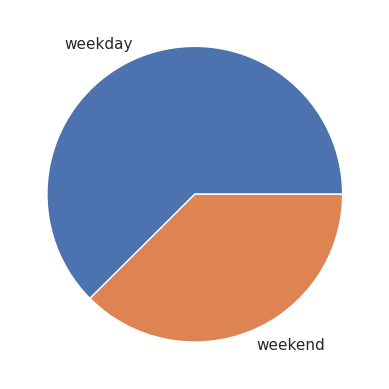

In [ ]:
daypart_sales.plot(kind='pie')

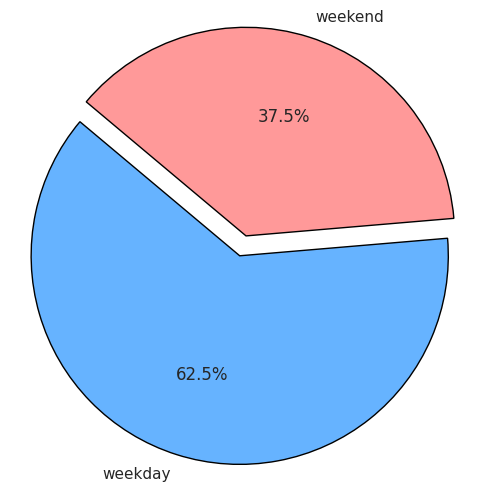

In [ ]:
daytype_counts = revised_df['weekday_weekend'].value_counts()
labels = daytype_counts.index
sizes = daytype_counts.values
colors = ['#66b3ff', '#ff9999']
explode=(0.1,0)
plt.figure(figsize=(6, 6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors, explode=explode ,startangle=140,wedgeprops={'edgecolor': 'black'})
plt.axis('equal')
plt.show()

In [ ]:
revised_df.head()

,Transaction,Item,date_time,period_day,weekday_weekend,Day,Time,Year,Month,day_name
0,1,Bread,2016-10-30 09:58:00,morning,weekend,30,09:58:00,2016,October,Sunday
1,2,Scandinavian,2016-10-30 10:05:00,morning,weekend,30,10:05:00,2016,October,Sunday
2,2,Scandinavian,2016-10-30 10:05:00,morning,weekend,30,10:05:00,2016,October,Sunday
3,3,Hot chocolate,2016-10-30 10:07:00,morning,weekend,30,10:07:00,2016,October,Sunday
4,3,Jam,2016-10-30 10:07:00,morning,weekend,30,10:07:00,2016,October,Sunday


In [ ]:
revised_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20507 entries, 0 to 20506
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Transaction      20507 non-null  int64         
 1   Item             20507 non-null  object        
 2   date_time        20507 non-null  datetime64[ns]
 3   period_day       20507 non-null  object        
 4   weekday_weekend  20507 non-null  object        
 5   Day              20507 non-null  int32         
 6   Time             20507 non-null  object        
 7   Year             20507 non-null  int32         
 8   Month            20507 non-null  object        
 9   day_name         20507 non-null  object        
dtypes: datetime64[ns](1), int32(2), int64(1), object(6)
memory usage: 1.4+ MB


In [ ]:
weekdays_daypart_sales=revised_df['weekday_weekend'].groupby(revised_df['period_day']).value_counts()
weekdays_daypart_sales

period_day  weekday_weekend
afternoon   weekday            7273
            weekend            4296
evening     weekday             356
            weekend             164
morning     weekday            5174
            weekend            3230
night       weekend              10
            weekday               4
Name: count, dtype: int64

In [ ]:
top_products_daytype = revised_df.groupby(['weekday_weekend', 'Item']).size().reset_index(name='count')

In [ ]:
top_products_daytype

,weekday_weekend,Item,count
0,weekday,Adjustment,1
1,weekday,Afternoon with the baker,18
2,weekday,Alfajores,232
3,weekday,Argentina Night,1
4,weekday,Art Tray,26
...,...,...,...
164,weekend,Tshirt,21
165,weekend,Valentine's card,7
166,weekend,Vegan Feast,12
167,weekend,Vegan mincepie,20


In [ ]:
top_products_daytype_sorted = top_products_daytype.sort_values(by=['weekday_weekend', 'count'], ascending=[True, False])
top_products_daytype_sorted

,weekday_weekend,Item,count
19,weekday,Coffee,3543
9,weekday,Bread,2092
76,weekday,Tea,976
13,weekday,Cake,612
61,weekday,Pastry,566
...,...,...,...
116,weekend,Empanadas,1
118,weekend,Fairy Doors,1
134,weekend,Lemon and coconut,1
138,weekend,Mortimer,1


In [ ]:
top_20_weekdays = top_products_daytype_sorted[top_products_daytype_sorted['weekday_weekend'] == 'weekday'].head(20)
top_20_weekends = top_products_daytype_sorted[top_products_daytype_sorted['weekday_weekend'] == 'weekend'].head(20)

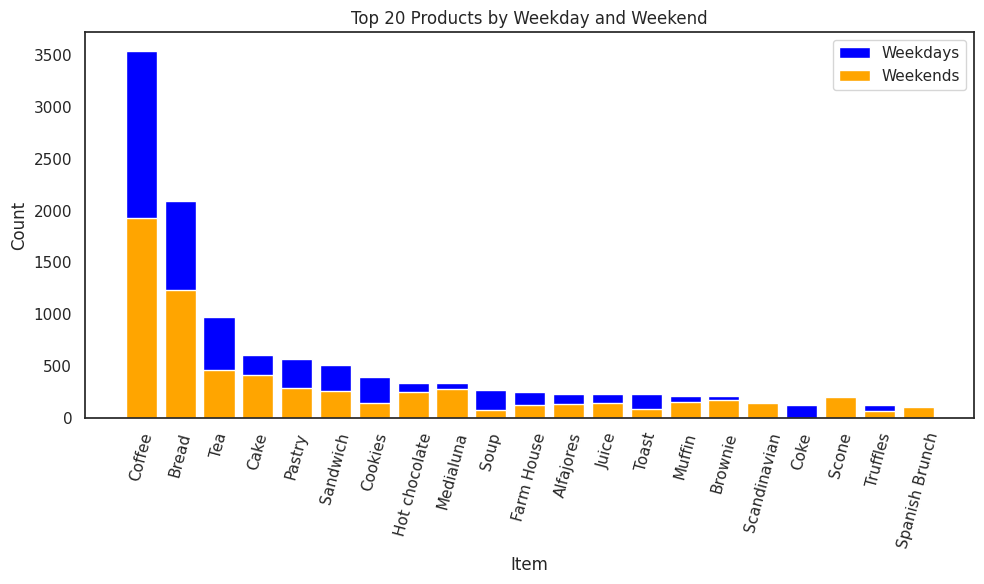

In [ ]:
plt.figure(figsize=(10, 6))
plt.bar(top_20_weekdays['Item'], top_20_weekdays['count'], label='Weekdays', color='blue')
plt.bar(top_20_weekends['Item'], top_20_weekends['count'], label='Weekends', color='orange')
plt.xlabel('Item')
plt.ylabel('Count')
plt.title('Top 20 Products by Weekday and Weekend')
plt.xticks(rotation=75)
plt.legend()
plt.tight_layout()
plt.show()

### top items sold per day part

In [ ]:
top_products_daypart = revised_df.groupby(['period_day', 'Item']).size().reset_index(name='count')

In [ ]:
top_products_daypart_sorted=top_products_daypart.sort_values(by=['period_day','count'],ascending=[True,False])
top_20_morning=top_products_daypart_sorted[top_products_daypart_sorted['period_day']=='morning'].head(20)
top_20_afternoon=top_products_daypart_sorted[top_products_daypart_sorted['period_day']=='afternoon'].head(20)
top_20_evening=top_products_daypart_sorted[top_products_daypart_sorted['period_day']=='evening'].head(20)
top_20_night=top_products_daypart_sorted[top_products_daypart_sorted['period_day']=='night'].head(20)

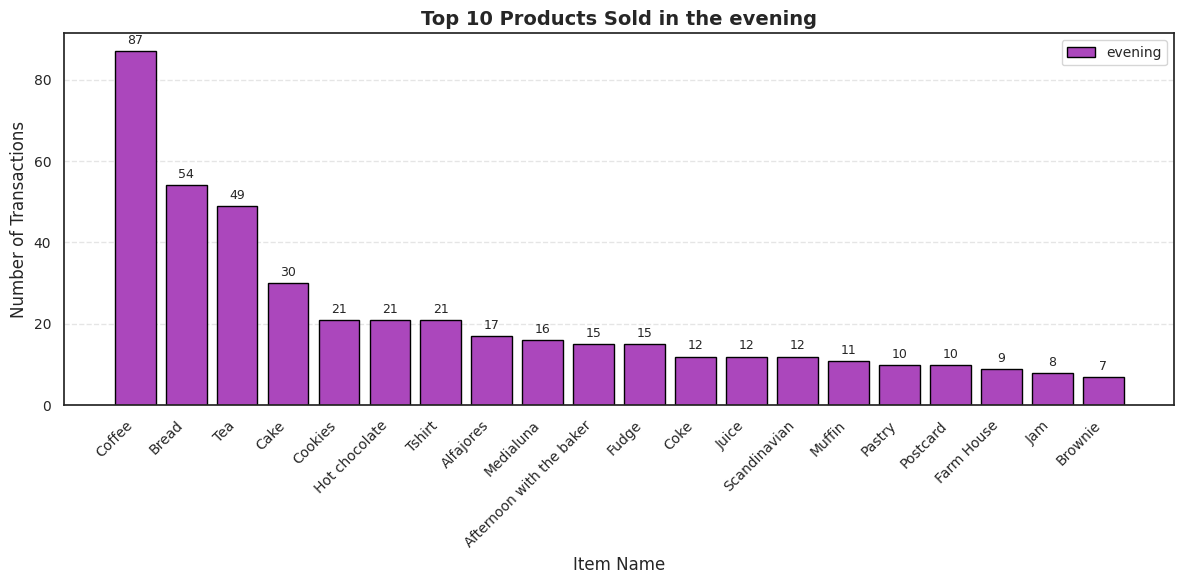

In [ ]:
import matplotlib.pyplot as plt

# Set up the figure
plt.figure(figsize=(12, 6))

# Bar chart
bars = plt.bar(top_20_evening['Item'], top_20_evening['count'], color='#AB47BC', edgecolor='black')

# Labels and title
plt.xlabel('Item Name', fontsize=12)
plt.ylabel('Number of Transactions', fontsize=12)
plt.title('Top 10 Products Sold in the evening', fontsize=14, weight='bold')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Optional: add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 1, str(height), ha='center', va='bottom', fontsize=9)

# Legend and layout
plt.legend(['evening'], loc='upper right', fontsize=10)
plt.tight_layout()
plt.show()

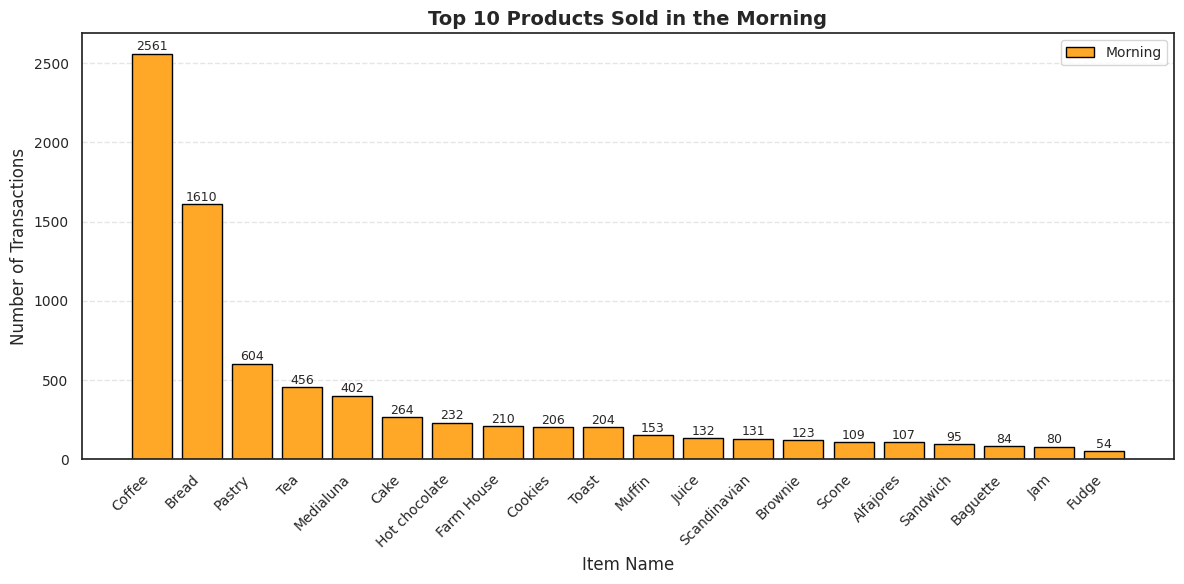

In [ ]:
plt.figure(figsize=(12, 6))

# Bar chart
bars = plt.bar(top_20_morning['Item'], top_20_morning['count'], color='#FFA726', edgecolor='black')

# Labels and title
plt.xlabel('Item Name', fontsize=12)
plt.ylabel('Number of Transactions', fontsize=12)
plt.title('Top 10 Products Sold in the Morning', fontsize=14, weight='bold')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Optional: add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 1, str(height), ha='center', va='bottom', fontsize=9)

# Legend and layout
plt.legend(['Morning'], loc='upper right', fontsize=10)
plt.tight_layout()
plt.show()

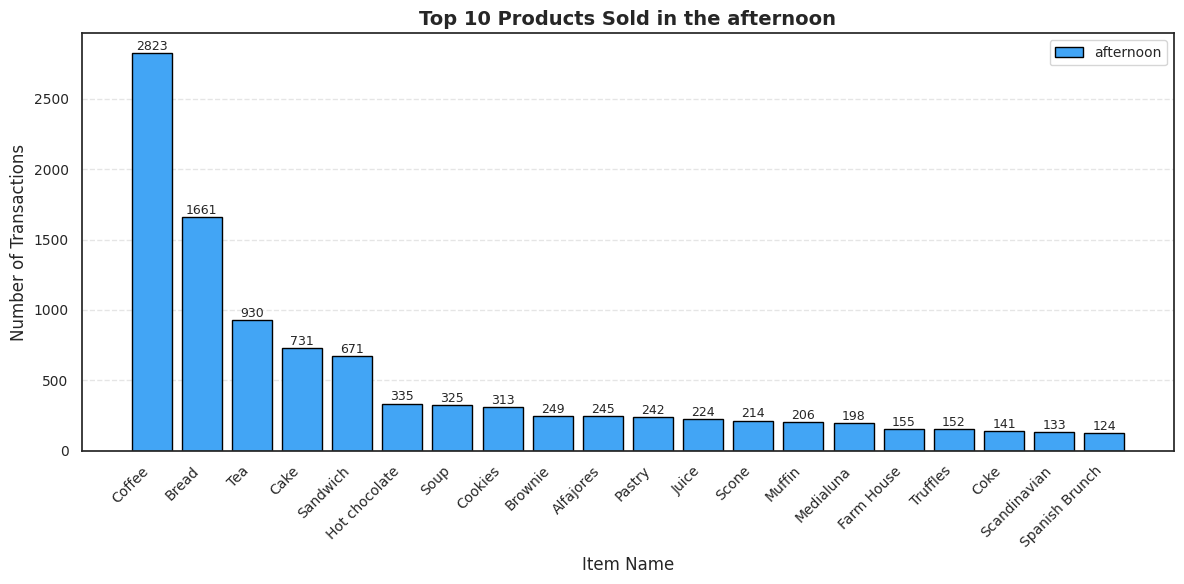

In [ ]:
plt.figure(figsize=(12, 6))

# Bar chart
bars = plt.bar(top_20_afternoon['Item'], top_20_afternoon['count'], color='#42A5F5', edgecolor='black')

# Labels and title
plt.xlabel('Item Name', fontsize=12)
plt.ylabel('Number of Transactions', fontsize=12)
plt.title('Top 10 Products Sold in the afternoon', fontsize=14, weight='bold')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Optional: add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 1, str(height), ha='center', va='bottom', fontsize=9)

# Legend and layout
plt.legend(['afternoon'], loc='upper right', fontsize=10)
plt.tight_layout()
plt.show()


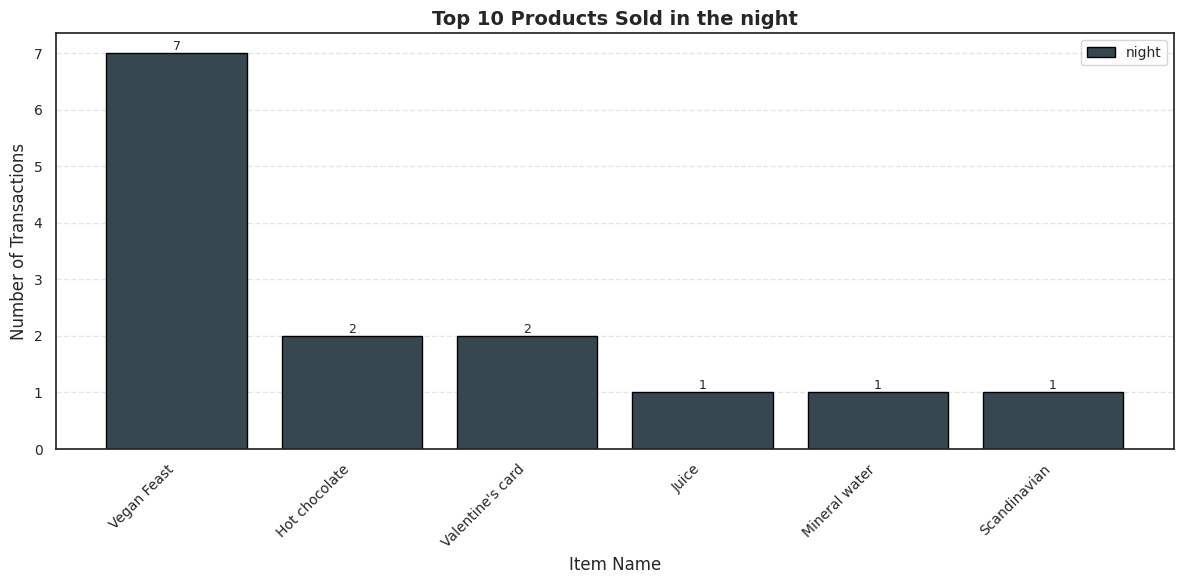

In [ ]:
plt.figure(figsize=(12, 6))

# Bar chart
bars = plt.bar(top_20_night['Item'], top_20_night['count'], color='#37474F', edgecolor='black')

# Labels and title
plt.xlabel('Item Name', fontsize=12)
plt.ylabel('Number of Transactions', fontsize=12)
plt.title('Top 10 Products Sold in the night', fontsize=14, weight='bold')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Optional: add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, str(height), ha='center', va='bottom', fontsize=9)

# Legend and layout
plt.legend(['night'], loc='upper right', fontsize=10)
plt.tight_layout()
plt.show()


In [ ]:
revised_df.head()

,Transaction,Item,date_time,period_day,weekday_weekend,Day,Time,Year,Month,day_name
0,1,Bread,2016-10-30 09:58:00,morning,weekend,30,09:58:00,2016,October,Sunday
1,2,Scandinavian,2016-10-30 10:05:00,morning,weekend,30,10:05:00,2016,October,Sunday
2,2,Scandinavian,2016-10-30 10:05:00,morning,weekend,30,10:05:00,2016,October,Sunday
3,3,Hot chocolate,2016-10-30 10:07:00,morning,weekend,30,10:07:00,2016,October,Sunday
4,3,Jam,2016-10-30 10:07:00,morning,weekend,30,10:07:00,2016,October,Sunday


In [ ]:
# import pandas as pd
# import seaborn as sns
# import matplotlib.pyplot as plt

# Load dataset
# Convert 'Date' and 'Time' to datetime
revised_df['Date'] = pd.to_datetime(revised_df['date_time'])
# df['Time'] = pd.to_datetime(df['Time'], format='%H:%M:%S').dt.time

# Create 'Hour' and 'Weekday' columns
revised_df['Hour'] = pd.to_datetime(revised_df['Time'], format='%H:%M:%S').dt.hour
revised_df['Weekday'] = revised_df['Date'].dt.day_name()  # e.g., Monday, Tuesday

In [ ]:
revised_df

,Transaction,Item,date_time,period_day,weekday_weekend,Day,Time,Year,Month,day_name,Date,Hour,Weekday
0,1,Bread,2016-10-30 09:58:00,morning,weekend,30,09:58:00,2016,October,Sunday,2016-10-30 09:58:00,9,Sunday
1,2,Scandinavian,2016-10-30 10:05:00,morning,weekend,30,10:05:00,2016,October,Sunday,2016-10-30 10:05:00,10,Sunday
2,2,Scandinavian,2016-10-30 10:05:00,morning,weekend,30,10:05:00,2016,October,Sunday,2016-10-30 10:05:00,10,Sunday
3,3,Hot chocolate,2016-10-30 10:07:00,morning,weekend,30,10:07:00,2016,October,Sunday,2016-10-30 10:07:00,10,Sunday
4,3,Jam,2016-10-30 10:07:00,morning,weekend,30,10:07:00,2016,October,Sunday,2016-10-30 10:07:00,10,Sunday
...,...,...,...,...,...,...,...,...,...,...,...,...,...
20502,9682,Coffee,2017-04-09 14:32:00,afternoon,weekend,9,14:32:00,2017,April,Sunday,2017-04-09 14:32:00,14,Sunday
20503,9682,Tea,2017-04-09 14:32:00,afternoon,weekend,9,14:32:00,2017,April,Sunday,2017-04-09 14:32:00,14,Sunday
20504,9683,Coffee,2017-04-09 14:57:00,afternoon,weekend,9,14:57:00,2017,April,Sunday,2017-04-09 14:57:00,14,Sunday
20505,9683,Pastry,2017-04-09 14:57:00,afternoon,weekend,9,14:57:00,2017,April,Sunday,2017-04-09 14:57:00,14,Sunday


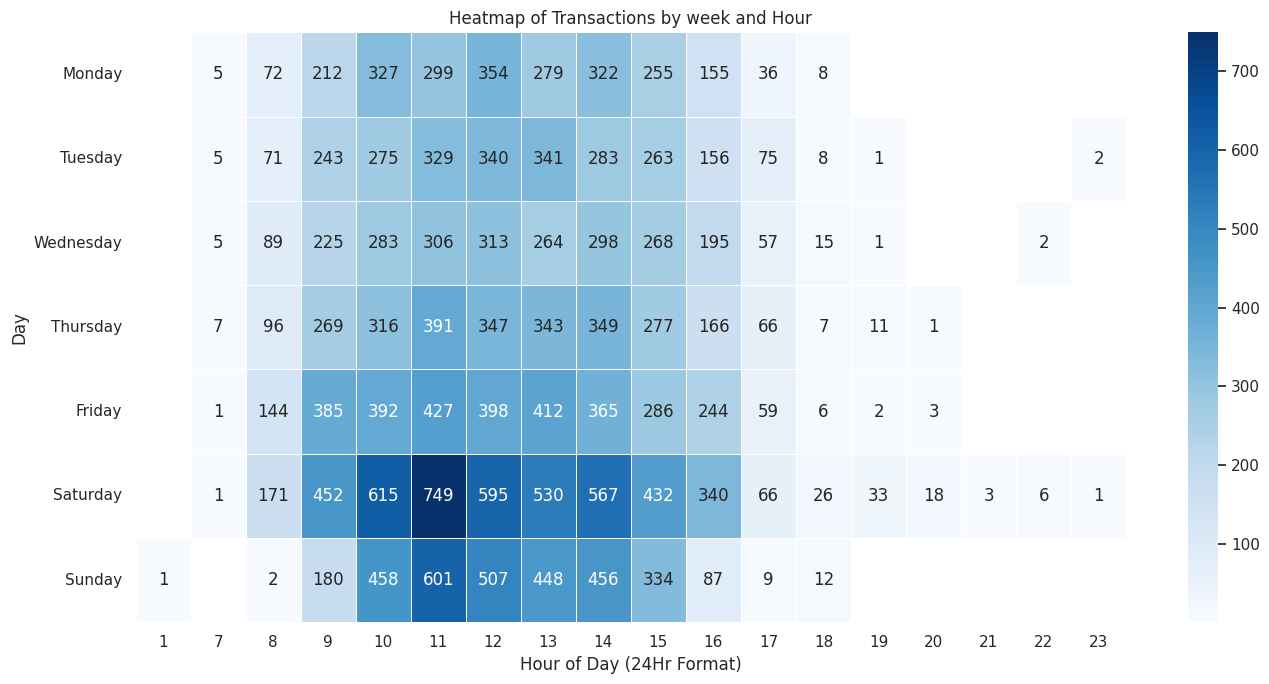

In [ ]:
# Group by Weekday and Hour
sales_pivot = revised_df.groupby(['Weekday', 'Hour']).size().reset_index(name='Count')

# Optional: Ensure weekday order
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sales_pivot['Weekday'] = pd.Categorical(sales_pivot['Weekday'], categories=weekday_order, ordered=True)

# Pivot for heatmap
heatmap_data = sales_pivot.pivot(index='Weekday', columns='Hour', values='Count')

# Plot heatmap
plt.figure(figsize=(14, 7))
sns.heatmap(heatmap_data, cmap='Blues', linewidths=0.5, annot=True, fmt='g')
plt.title('Heatmap of Transactions by week and Hour')
plt.xlabel('Hour of Day (24Hr Format)')
plt.ylabel('Day')
plt.tight_layout()
plt.show()

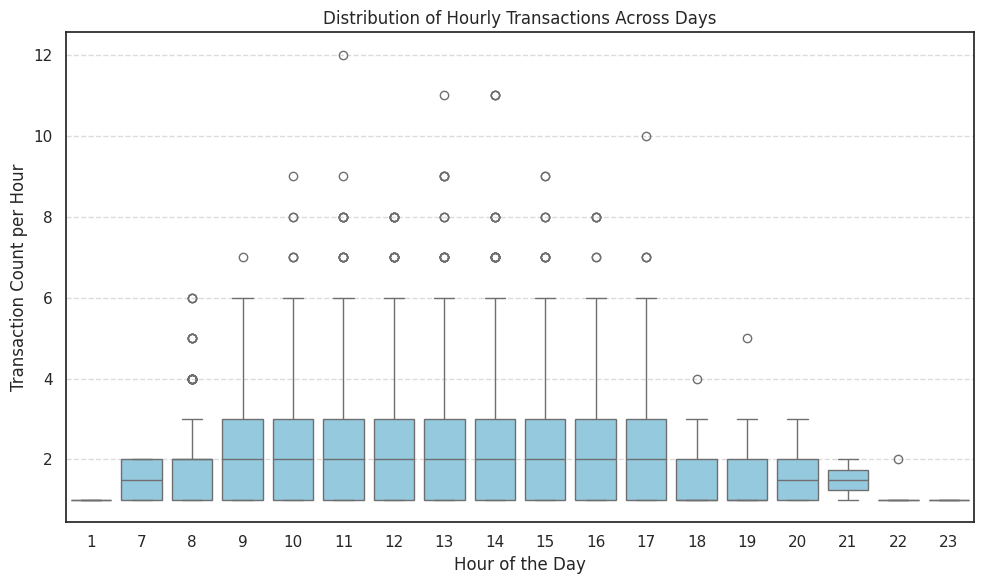

In [ ]:
# Count transactions per hour per day
hourly_counts = revised_df.groupby(['Date', 'Hour']).size().reset_index(name='Transaction_Count')

# Plot boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x='Hour', y='Transaction_Count', data=hourly_counts, color='skyblue')
plt.title('Distribution of Hourly Transactions Across Days')
plt.ylabel('Transaction Count per Hour')
plt.xlabel('Hour of the Day')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

<Axes: xlabel='Date'>

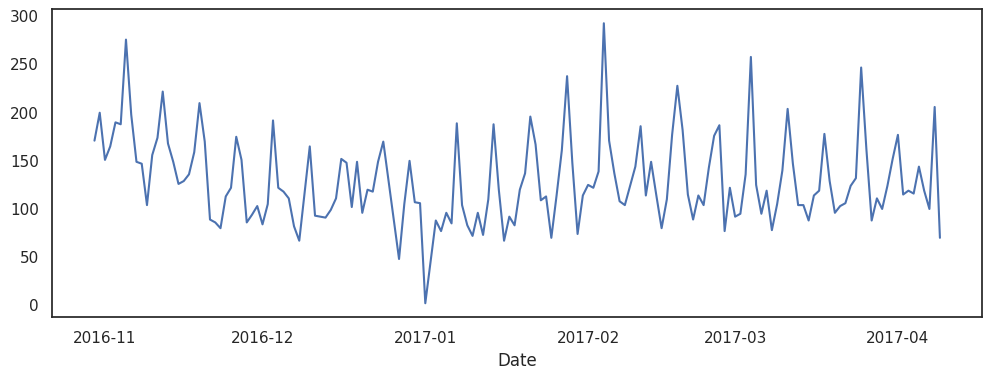

In [ ]:
daily_sales = revised_df.groupby(revised_df['Date'].dt.date).size()
daily_sales.plot(kind='line', figsize=(12,4))

<Axes: xlabel='Weekday'>

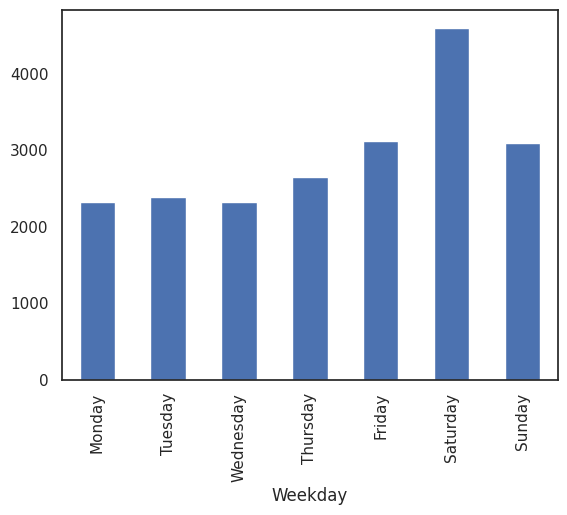

In [ ]:
revised_df['Weekday'] = pd.Categorical(revised_df['Weekday'], categories=[
    'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'], ordered=True)
revised_df['Weekday'].value_counts().sort_index().plot(kind='bar')

In [ ]:
# Extract year and month from DateTime to group by month
# revised_df['Month'] = revised_df['DateTime'].dt.to_period('M')

# Group by Month and Item to count the number of products sold
top_products_month = revised_df.groupby(['Month', 'Item']).size().reset_index(name='count')

# Sort the data by Month and count to rank the products
top_products_month_sorted = top_products_month.sort_values(by=['Month', 'count'], ascending=[True, False])

# Get the top 10 products for each month
top_10_products_month = top_products_month_sorted.groupby('Month').head(10)

# Display the result
print(top_10_products_month)

       Month               Item  count
13     April             Coffee    290
5      April              Bread    175
43     April                Tea     73
8      April               Cake     72
36     April           Sandwich     57
..       ...                ...    ...
327  October       Scandinavian     16
319  October          Medialuna     13
315  October  Hearty & Seasonal     12
309  October            Cookies     11
311  October         Farm House     11

[70 rows x 3 columns]


['April' 'December' 'February' 'January' 'March' 'November' 'October']


/tmp/ipython-input-1265973384.py:10: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




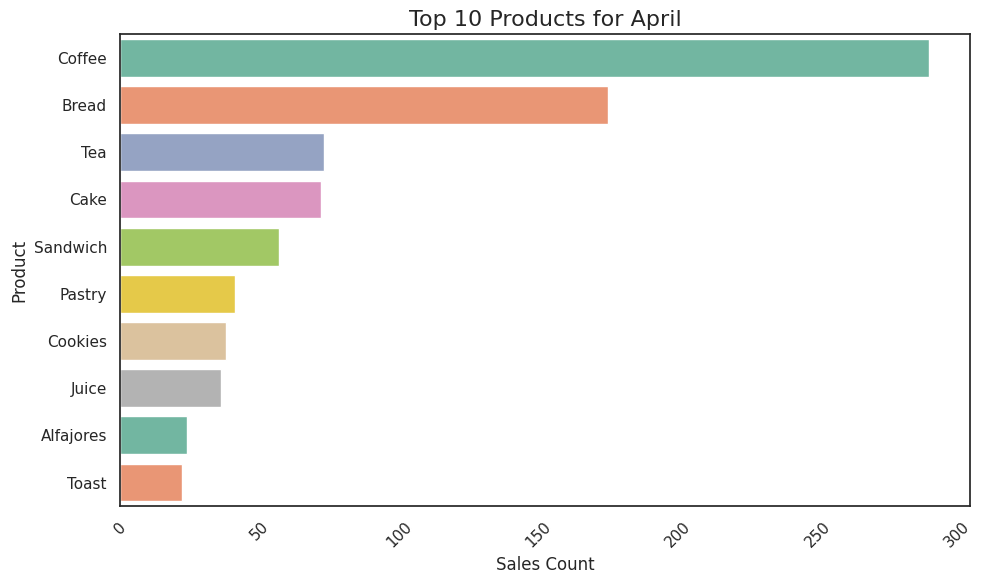

/tmp/ipython-input-1265973384.py:10: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




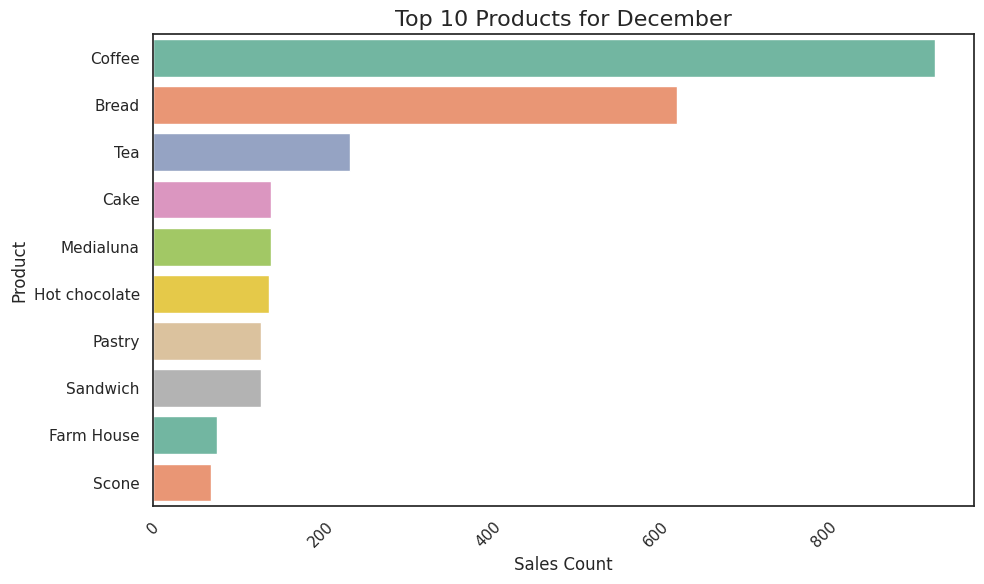

/tmp/ipython-input-1265973384.py:10: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




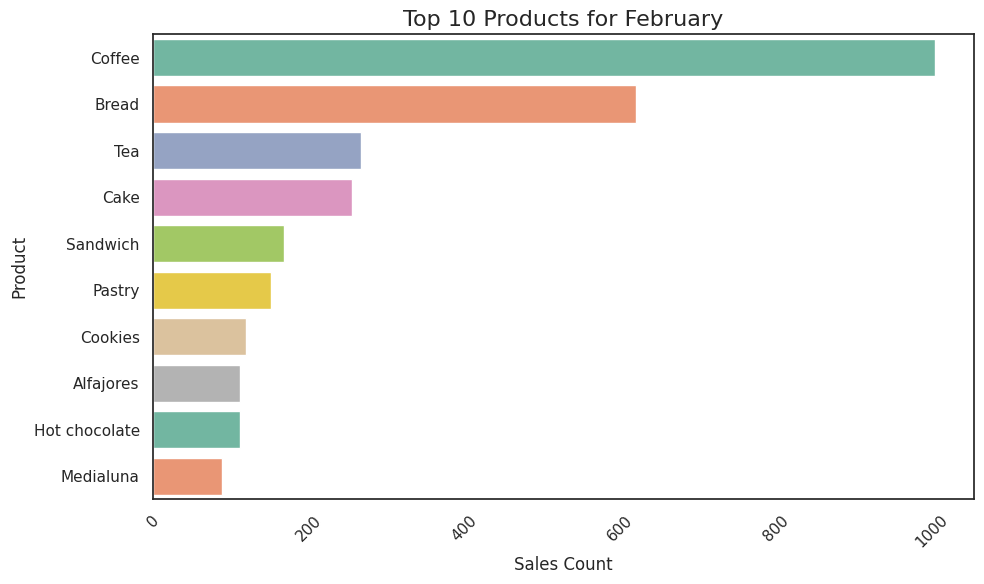

/tmp/ipython-input-1265973384.py:10: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




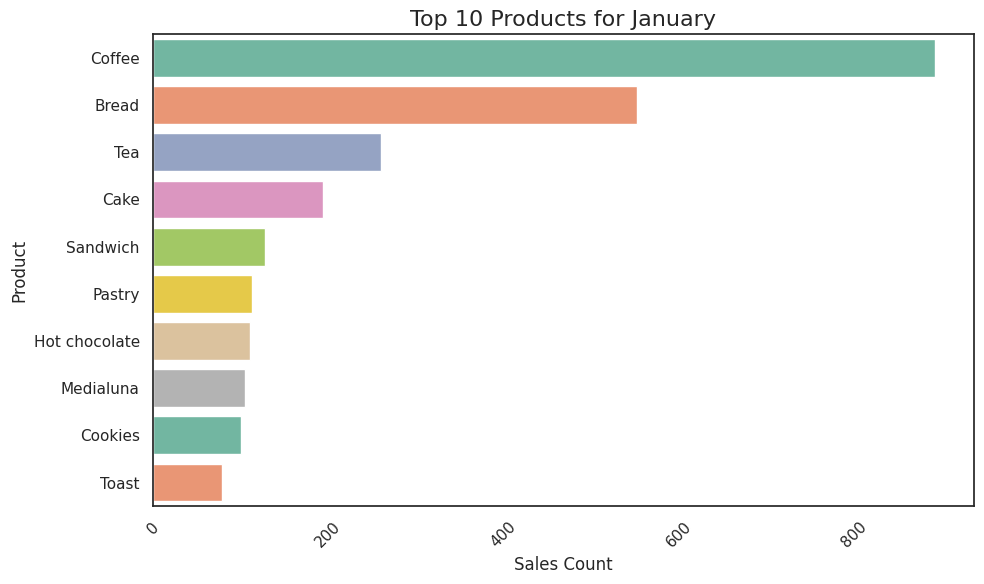

/tmp/ipython-input-1265973384.py:10: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




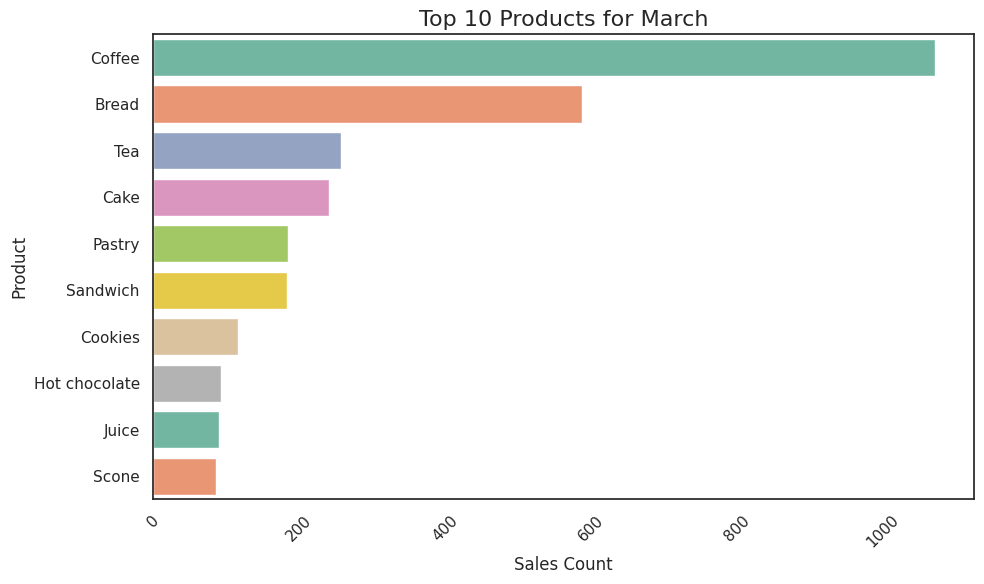

/tmp/ipython-input-1265973384.py:10: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




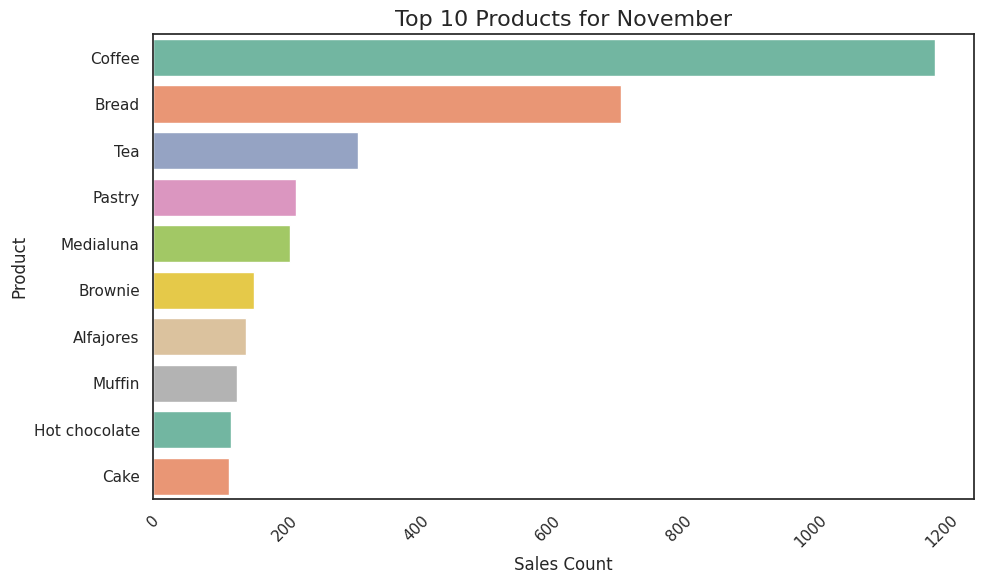

/tmp/ipython-input-1265973384.py:10: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




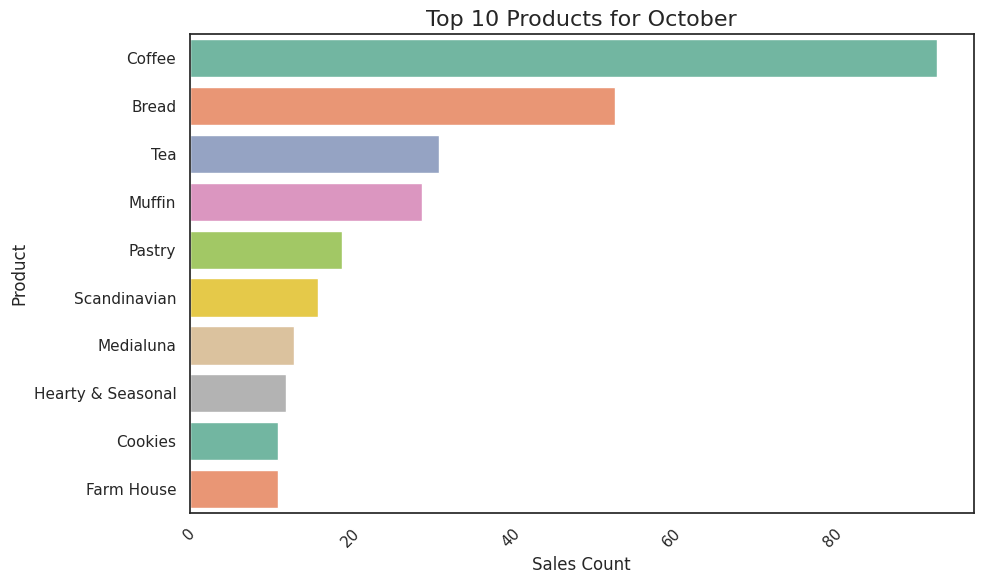

In [ ]:
months = top_10_products_month['Month'].unique()
print(months)
# Create individual plots for each month
for month in months:
    # Filter the data for the current month
    month_data = top_10_products_month[top_10_products_month['Month'] == month]

    # Plot the data for the current month
    plt.figure(figsize=(10, 6))
    sns.barplot(x='count', y='Item', data=month_data, palette='Set2')

    # Set titles and labels
    plt.title(f"Top 10 Products for {month}", fontsize=16)
    plt.xlabel("Sales Count")
    plt.ylabel("Product")
    plt.xticks(rotation=45)
    plt.tight_layout()

    # Show the plot for the current month
    plt.show()

/tmp/ipython-input-2337831049.py:6: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipython-input-2337831049.py:6: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipython-input-2337831049.py:6: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipython-input-2337831049.py:6: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




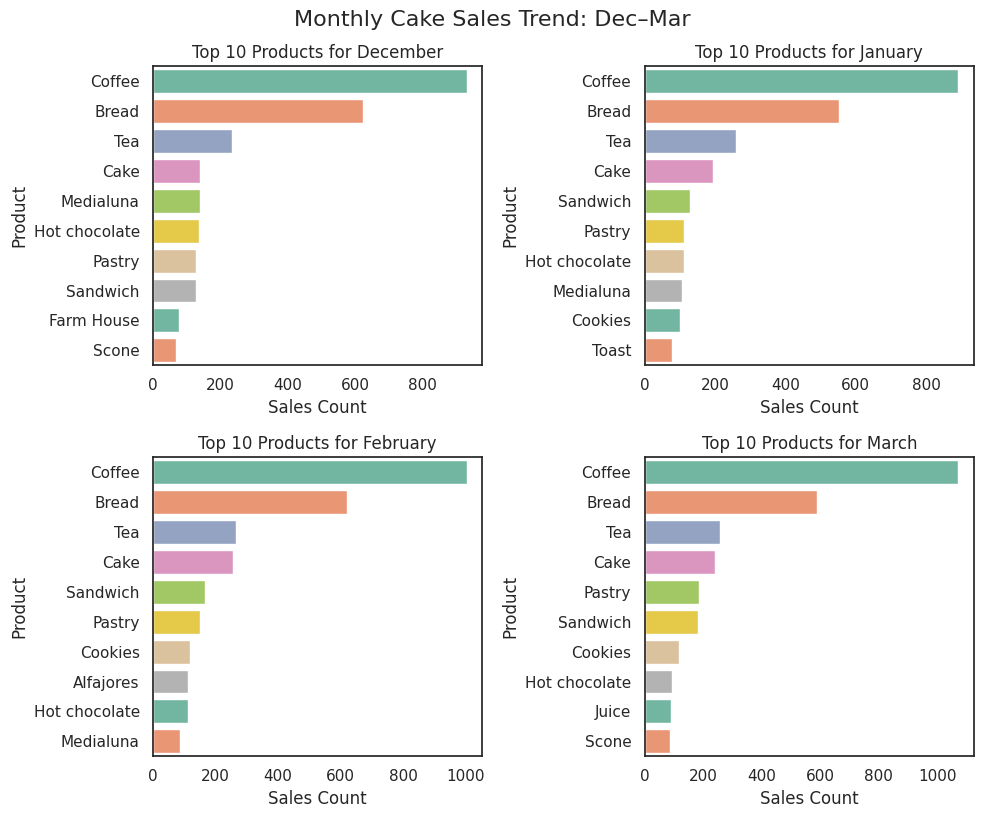

In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(10, 8))
months = ['December', 'January', 'February', 'March']

for ax, month in zip(axs.flat, months):
    df = top_10_products_month[top_10_products_month['Month'] == month]
    sns.barplot(x='count', y='Item', data=df, ax=ax, palette='Set2')
    ax.set_title(f"Top 10 Products for {month}")
    ax.set_xlabel("Sales Count")
    ax.set_ylabel("Product")

plt.tight_layout()
plt.suptitle("Monthly Cake Sales Trend: Dec–Mar", fontsize=16, y=1.02)
plt.show()


#MBA

In [ ]:
import pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules

# Step 1: Prepare data
# Create basket format: Transaction × Item (one-hot encoded)
basket = revised_df.groupby(['Transaction', 'Item'])['Item'].count().unstack().fillna(0)
basket = basket.applymap(lambda x: 1 if x > 0 else 0)

# Step 2: Generate frequent itemsets
frequent_itemsets = apriori(basket, min_support=0.005, use_colnames=True)

# Step 3: Generate association rules
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.3)

# Sort by lift or confidence
rules = rules.sort_values(by='lift', ascending=False)

# Display top rules
rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(20)

/tmp/ipython-input-4115858519.py:7: FutureWarning:

DataFrame.applymap has been deprecated. Use DataFrame.map instead.

/usr/local/lib/python3.11/dist-packages/mlxtend/frequent_patterns/fpcommon.py:161: DeprecationWarning:

DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type



,antecedents,consequents,support,confidence,lift
12,(Keeping It Local),(Coffee),0.005388,0.809524,1.692169
24,(Toast),(Coffee),0.023666,0.704403,1.472431
17,(Salad),(Coffee),0.006550,0.626263,1.309094
32,"(Hot chocolate, Cake)",(Coffee),0.006867,0.601852,1.258067
21,(Spanish Brunch),(Coffee),0.010882,0.598837,1.251766
13,(Medialuna),(Coffee),0.035182,0.569231,1.189878
16,(Pastry),(Coffee),0.047544,0.552147,1.154168
23,(Tiffin),(Coffee),0.008452,0.547945,1.145385
0,(Alfajores),(Coffee),0.019651,0.540698,1.130235
8,(Hearty & Seasonal),(Coffee),0.005705,0.540000,1.128777


In [ ]:
# Remove 'Keeping It Local' from every transaction list
df_grouped['Item'] = df_grouped['Item'].apply(lambda items: [item for item in items if item != 'Keeping It Local'])
# Count all items
from collections import Counter
all_items = [item for sublist in df_grouped['Item'] for item in sublist]
item_counts = Counter(all_items)

# See least common items
[item for item, count in item_counts.items() if count < 5]
transactions = df_grouped['Item'].tolist()

In [ ]:
from mlxtend.preprocessing import TransactionEncoder

# One-hot encode
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)

basket_df = pd.DataFrame(te_ary, columns=te.columns_)
basket_df.head()

,Adjustment,Afternoon with the baker,Alfajores,Argentina Night,Art Tray,Bacon,Baguette,Bakewell,Bare Popcorn,Basket,...,The BART,The Nomad,Tiffin,Toast,Truffles,Tshirt,Valentine's card,Vegan Feast,Vegan mincepie,Victorian Sponge
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
from mlxtend.frequent_patterns import apriori, association_rules

# Generate frequent itemsets
frequent_itemsets = apriori(basket_df, min_support=0.005, use_colnames=True)

# Generate association rules
rules = association_rules(frequent_itemsets, metric='confidence', min_threshold=0.3)

# Sort by lift or confidence
rules = rules.sort_values(by='lift', ascending=False)

In [ ]:
rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
23,(Toast),(Coffee),0.033597,0.478394,0.023666,0.704403,1.472431,1.0,0.007593,1.764582,0.332006,0.048464,0.433293,0.376936
16,(Salad),(Coffee),0.010460,0.478394,0.006550,0.626263,1.309094,1.0,0.001547,1.395648,0.238608,0.013582,0.283487,0.319978
31,"(Hot chocolate, Cake)",(Coffee),0.011410,0.478394,0.006867,0.601852,1.258067,1.0,0.001409,1.310080,0.207497,0.014220,0.236688,0.308103
20,(Spanish Brunch),(Coffee),0.018172,0.478394,0.010882,0.598837,1.251766,1.0,0.002189,1.300235,0.204851,0.022406,0.230908,0.310792
12,(Medialuna),(Coffee),0.061807,0.478394,0.035182,0.569231,1.189878,1.0,0.005614,1.210871,0.170091,0.069665,0.174148,0.321387
15,(Pastry),(Coffee),0.086107,0.478394,0.047544,0.552147,1.154168,1.0,0.006351,1.164682,0.146161,0.091968,0.141396,0.325764
22,(Tiffin),(Coffee),0.015425,0.478394,0.008452,0.547945,1.145385,1.0,0.001073,1.153856,0.128919,0.017414,0.133340,0.282807
0,(Alfajores),(Coffee),0.036344,0.478394,0.019651,0.540698,1.130235,1.0,0.002264,1.135648,0.119574,0.039693,0.119446,0.290888
8,(Hearty & Seasonal),(Coffee),0.010565,0.478394,0.005705,0.540000,1.128777,1.0,0.000651,1.133926,0.115303,0.011806,0.118108,0.275963
11,(Juice),(Coffee),0.038563,0.478394,0.020602,0.534247,1.116750,1.0,0.002154,1.119919,0.108738,0.041507,0.107078,0.288656


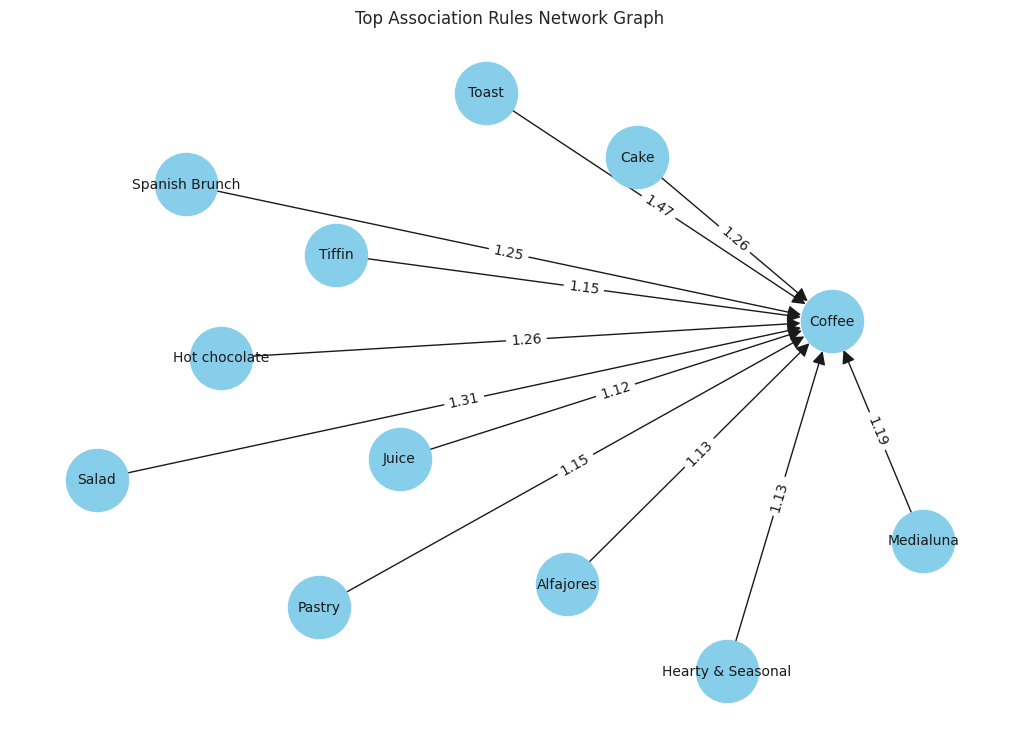

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

# Create graph
G = nx.DiGraph()

for i, row in rules.head(10).iterrows():
    for antecedent in row['antecedents']:
        for consequent in row['consequents']:
            G.add_edge(antecedent, consequent, weight=row['lift'])

plt.figure(figsize=(10,7))
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, with_labels=True, node_color='skyblue', node_size=2000, font_size=10, arrowsize=20)
labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels={k: f"{v:.2f}" for k,v in labels.items()})
plt.title("Top Association Rules Network Graph")
plt.show()

In [ ]:
frequent_itemsets = apriori(basket_df, min_support=0.02, use_colnames=True)
rules = association_rules(frequent_itemsets, metric='confidence', min_threshold=1)
# Clean up frozenset
rules['antecedents'] = rules['antecedents'].apply(lambda x: next(iter(x)))
rules['consequents'] = rules['consequents'].apply(lambda x: next(iter(x)))

# rules = rules.sort_values(by='lift', ascending=False)

In [ ]:
from mlxtend.frequent_patterns import apriori, association_rules

# Generate frequent itemsets
frequent_itemsets = apriori(basket_df, min_support=0.02, use_colnames=True)
# Generate association rules
rules = association_rules(frequent_itemsets, metric='confidence', min_threshold=0.1)
rules=rules[rules['lift']>=0.5]
rules['antecedents'] = rules['antecedents'].apply(lambda x: next(iter(x)))
rules['consequents'] = rules['consequents'].apply(lambda x: next(iter(x)))
# Sort by lift or confidence
rules = rules.sort_values(by='lift', ascending=False)

In [ ]:
len(rules)

18

In [ ]:
# Step 1: Build product network
source_items = list(rules["antecedents"].unique())
target_items = list(rules["consequents"].unique())
all_items = list(set(source_items + target_items))

G = nx.Graph()
G.add_nodes_from(all_items)

# Step 2: Add edges from rules
for _, row in rules.iterrows():
    G.add_edge(row["antecedents"], row["consequents"])

# Step 3: Layout
positions = nx.spring_layout(G, k=0.5, iterations=100)
for item, coord in positions.items():
    G.nodes[item]['pos'] = coord

# Step 4: Plotly edge and node traces
edge_trace = go.Scatter(x=[], y=[], mode='lines', line=dict(width=0.5, color='gray'), hoverinfo='none')
for edge in G.edges():
    x0, y0 = G.nodes[edge[0]]['pos']
    x1, y1 = G.nodes[edge[1]]['pos']
    edge_trace['x'] += tuple([x0, x1, None])
    edge_trace['y'] += tuple([y0, y1, None])

node_trace = go.Scatter(
    x=[], y=[], mode='markers+text', hoverinfo='text',
    marker=dict(showscale=True, colorscale='YlOrRd', reversescale=True, size=15, color=[], colorbar=dict(title='Connections')),
    text=[]
)

for node in G.nodes():
    x, y = G.nodes[node]['pos']
    node_trace['x'] += (x,)
    node_trace['y'] += (y,)
    node_trace['marker']['color'] += (len(list(G.neighbors(node))),)
    node_trace['text'] += (f"{node}<br>Connections: {len(list(G.neighbors(node)))}",)

# Step 5: Build figure
fig = go.Figure(data=[edge_trace, node_trace], layout=go.Layout(
    title='Association Rule Network', titlefont_size=25,
    showlegend=False, plot_bgcolor='white',
    xaxis=dict(showgrid=False, zeroline=False),
    yaxis=dict(showgrid=False, zeroline=False)
))

iplot(fig)

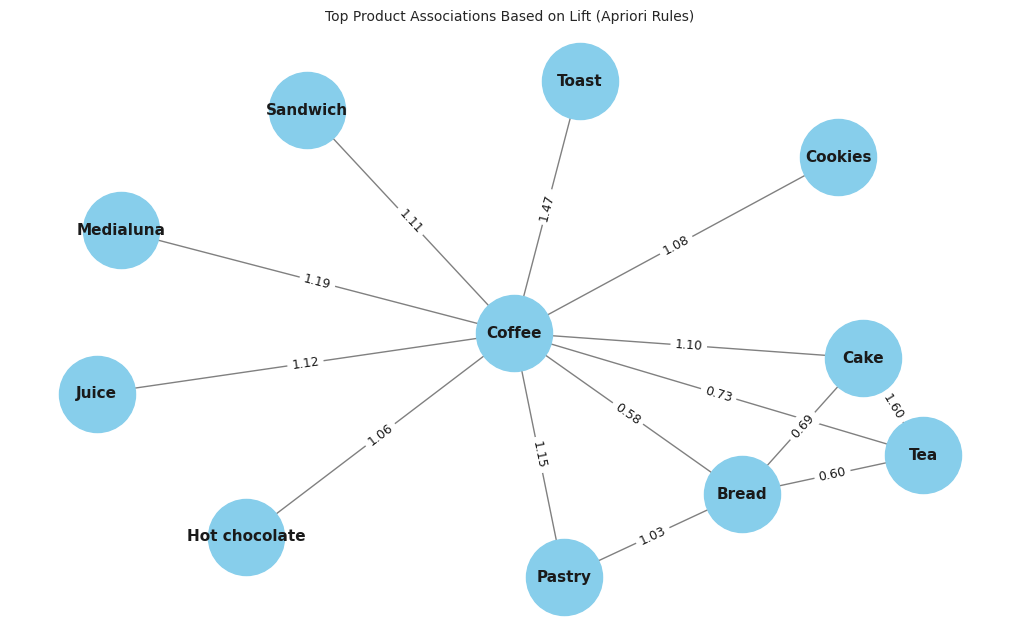

In [ ]:
# Step 1: Initialize graph
G = nx.Graph()

# Step 2: Add edges from refined association rules (assuming rule has 'antecedents', 'consequents', 'lift')
for _, row in rules.iterrows():
    G.add_edge(row["antecedents"], row["consequents"], lift=row["lift"])


# Step 3: Layout positions for nodes
pos = nx.spring_layout(G, k=0.7, iterations=400,dim=2)

# Step 4: Draw graph
plt.figure(figsize=(10,6))
nx.draw(
    G, pos,
    with_labels=True,
    node_size=3000,
    node_color="skyblue",
    font_size=11,
    font_weight="bold",
    edge_color="gray"
)

# Step 5: Add lift values as edge labels
edge_labels = {
    (u, v): f"{d['lift']:.2f}" for u, v, d in G.edges(data=True)
}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=9)

# Step 6: Title
plt.title("Top Product Associations Based on Lift (Apriori Rules)", fontsize=10)
plt.axis("off")
plt.show()

# Sales forecasting

In [ ]:
revised_df.head()

,Transaction,Item,date_time,period_day,weekday_weekend,Day,Time,Year,Month,day_name,Date,Hour,Weekday
0,1,Bread,2016-10-30 09:58:00,morning,weekend,30,09:58:00,2016,October,Sunday,2016-10-30 09:58:00,9,Sunday
1,2,Scandinavian,2016-10-30 10:05:00,morning,weekend,30,10:05:00,2016,October,Sunday,2016-10-30 10:05:00,10,Sunday
2,2,Scandinavian,2016-10-30 10:05:00,morning,weekend,30,10:05:00,2016,October,Sunday,2016-10-30 10:05:00,10,Sunday
3,3,Hot chocolate,2016-10-30 10:07:00,morning,weekend,30,10:07:00,2016,October,Sunday,2016-10-30 10:07:00,10,Sunday
4,3,Jam,2016-10-30 10:07:00,morning,weekend,30,10:07:00,2016,October,Sunday,2016-10-30 10:07:00,10,Sunday


In [ ]:
revised_df['Date'] = pd.to_datetime(revised_df['Date'])

# Group by date to count number of transactions per day
daily_sales = revised_df.groupby(revised_df['Date'].dt.date).size().reset_index(name='sales')
daily_sales.columns = ['Date', 'Sales']
daily_sales['Date'] = pd.to_datetime(daily_sales['Date'])

# Set Date as index
daily_sales.set_index('Date', inplace=True)

In [ ]:
daily_sales

,Sales
Date,
2016-10-30,170
2016-10-31,199
2016-11-01,150
2016-11-02,164
2016-11-03,189
...,...
2017-04-05,143
2017-04-06,118
2017-04-07,99


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning:

No supported index is available. Prediction results will be given with an integer index beginning at `start`.

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning:

No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.



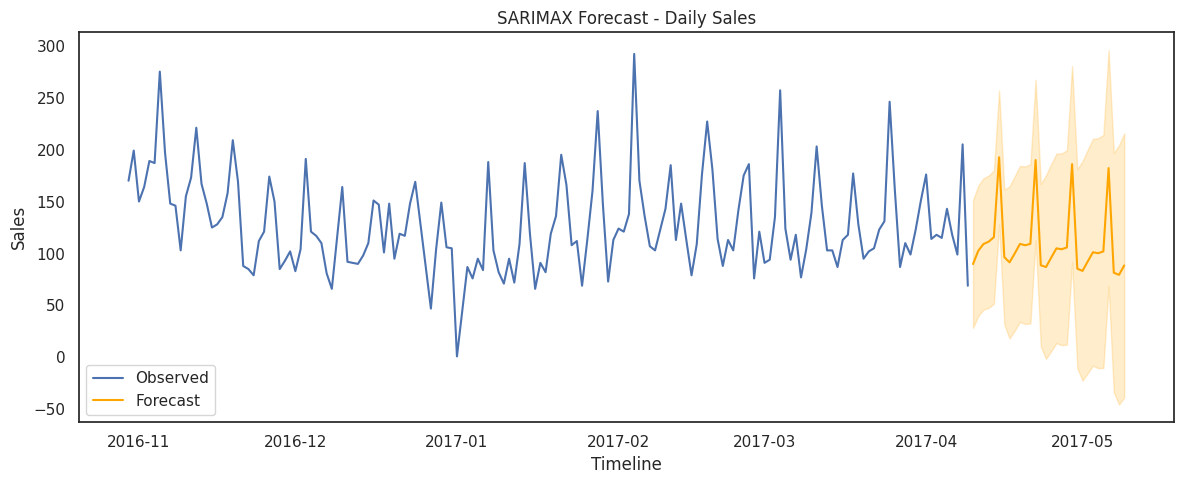

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import matplotlib.pyplot as plt

# Fit SARIMAX model (you can tune (p,d,q) and (P,D,Q,s))
model = SARIMAX(daily_sales['Sales'], order=(1,1,1), seasonal_order=(1,1,1,7))
results = model.fit(disp=False)

# Forecast next 30 days
forecast = results.get_forecast(steps=30)
forecast_ci = forecast.conf_int()
# Fix the forecast index (extend the original date index)
forecast_index = pd.date_range(start=daily_sales.index[-1] + pd.Timedelta(days=1), periods=30)
forecast_mean = forecast.predicted_mean
forecast_mean.index = forecast_index
forecast_ci.index = forecast_index

# Plot results
plt.figure(figsize=(12,5))
plt.plot(daily_sales['Sales'], label='Observed')
plt.plot(forecast_mean, label='Forecast', color='orange')
plt.fill_between(forecast_ci.index, forecast_ci.iloc[:, 0], forecast_ci.iloc[:, 1], color='orange', alpha=0.2)
plt.title('SARIMAX Forecast - Daily Sales')
plt.xlabel('Timeline')
plt.ylabel('Sales')
plt.legend()
plt.tight_layout()
plt.show()

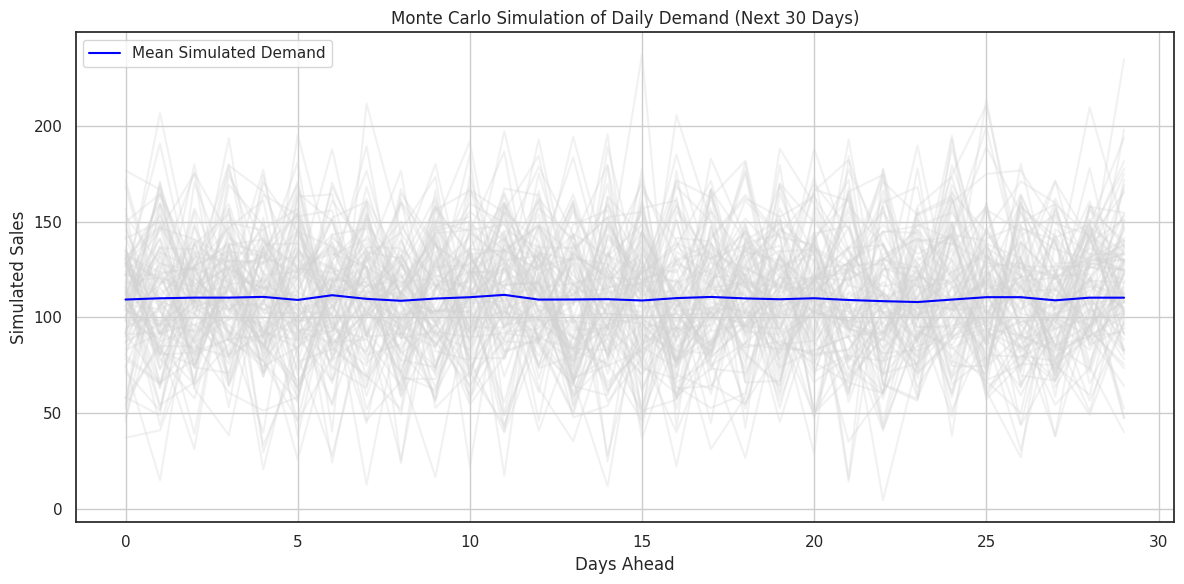

In [ ]:
import numpy as np

# Step 1: Extract forecasted values from SARIMAX
forecast_values = forecast.predicted_mean
mean_demand = forecast_values.mean()
std_demand = forecast_values.std()

# Step 2: Simulate 1000 scenarios of daily demand for 30 days
np.random.seed(42)
simulated_demand = np.random.normal(loc=mean_demand, scale=std_demand, size=(1000, 30))

# Step 3: Calculate statistics
simulated_mean_demand = np.mean(simulated_demand, axis=0)
simulated_std_demand = np.std(simulated_demand, axis=0)

# Optional: Plot simulated scenarios
plt.figure(figsize=(12, 6))
for i in range(100):  # plot only 100 of the 1000 simulations for visibility
    plt.plot(simulated_demand[i], color='lightgray', alpha=0.3)
plt.plot(simulated_mean_demand, color='blue', label='Mean Simulated Demand')
plt.title("Monte Carlo Simulation of Daily Demand (Next 30 Days)")
plt.xlabel("Days Ahead")
plt.ylabel("Simulated Sales")
plt.legend()
plt.tight_layout()
plt.grid(True)
plt.show()

In [ ]:
hourly_data

,0
date_time,
2016-10-30 09:00:00,1
2016-10-30 10:00:00,57
2016-10-30 11:00:00,28
2016-10-30 12:00:00,33
2016-10-30 13:00:00,34
...,...
2017-04-09 11:00:00,17
2017-04-09 12:00:00,15
2017-04-09 13:00:00,8


In [ ]:
daily_sales.drop(columns=['date'],inplace=True)

KeyError: "['date'] not found in axis"

In [ ]:
daily_sales

In [ ]:
revised_df.head()

In [ ]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Step 1: Aggregate daily sales
daily_sales_1 = revised_df.copy()
daily_sales_1['date'] = pd.to_datetime(daily_sales_1['date_time']).dt.date
daily_agg = daily_sales_1.groupby('date').size().reset_index(name='sales')
daily_agg['date'] = pd.to_datetime(daily_agg['date'])

# Step 2: Feature Engineering
daily_agg['day'] = daily_agg['date'].dt.day
daily_agg['month'] = daily_agg['date'].dt.month
daily_agg['weekday'] = daily_agg['date'].dt.weekday
daily_agg['dayofyear'] = daily_agg['date'].dt.dayofyear

# Step 3: Feature matrix and target
X = daily_agg[['day', 'month', 'weekday', 'dayofyear']]
y = daily_agg['sales']

# Step 4: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=False, test_size=0.2)

# Step 5: Fit XGBoost model
model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=3)
model.fit(X_train, y_train)

# Step 6: Predict and evaluate
y_pred = model.predict(X_test)

print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))

# Step 7: Plot results
plt.figure(figsize=(12,6))
plt.plot(y_test.values, label='Actual', marker='o')
plt.plot(y_pred, label='Predicted', marker='x')
plt.title("XGBoost Forecast vs Actual Sales")
plt.xlabel("Date of Month")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
X

In [ ]:
daily_agg

In [ ]:
import numpy as np

In [ ]:
np.__version__

In [ ]:
model

### SARIMAX WITH EXoG

In [ ]:
revised_df.head()

,Transaction,Item,date_time,period_day,weekday_weekend,Day,Time,Year,Month,day_name,Date,Hour,Weekday
0,1,Bread,2016-10-30 09:58:00,morning,weekend,30,09:58:00,2016,October,Sunday,2016-10-30 09:58:00,9,Sunday
1,2,Scandinavian,2016-10-30 10:05:00,morning,weekend,30,10:05:00,2016,October,Sunday,2016-10-30 10:05:00,10,Sunday
2,2,Scandinavian,2016-10-30 10:05:00,morning,weekend,30,10:05:00,2016,October,Sunday,2016-10-30 10:05:00,10,Sunday
3,3,Hot chocolate,2016-10-30 10:07:00,morning,weekend,30,10:07:00,2016,October,Sunday,2016-10-30 10:07:00,10,Sunday
4,3,Jam,2016-10-30 10:07:00,morning,weekend,30,10:07:00,2016,October,Sunday,2016-10-30 10:07:00,10,Sunday


In [ ]:
daily_sales

,Sales
Date,
2016-10-30,170
2016-10-31,199
2016-11-01,150
2016-11-02,164
2016-11-03,189
...,...
2017-04-05,143
2017-04-06,118
2017-04-07,99


In [ ]:
df = daily_sales.copy()
df['weekday_weekend'] = df.index.map(lambda x: 'weekend' if x.weekday() > 5 else 'weekday')

In [ ]:
print(df.head())

            Sales weekday_weekend
Date                             
2016-10-30    170         weekend
2016-10-31    199         weekday
2016-11-01    150         weekday
2016-11-02    164         weekday
2016-11-03    189         weekday


In [ ]:
daily_sales

,Sales
Date,
2016-10-30,170
2016-10-31,199
2016-11-01,150
2016-11-02,164
2016-11-03,189
...,...
2017-04-05,143
2017-04-06,118
2017-04-07,99


In [ ]:
prophet_df.columns = ['y']
prophet_df['ds'] = prophet_df.index
prophet_df = prophet_df[['ds', 'y']]

NameError: name 'prophet_df' is not defined

### XGBoost with time series feature

In [ ]:
from prophet import Prophet
prophet_df = daily_sales.copy()
prophet_df = prophet_df.reset_index()
prophet_df.columns = ['ds', 'y']

In [ ]:
prophet_df

,ds,y
0,2016-10-30,170
1,2016-10-31,199
2,2016-11-01,150
3,2016-11-02,164
4,2016-11-03,189
...,...,...
154,2017-04-05,143
155,2017-04-06,118
156,2017-04-07,99
157,2017-04-08,205


In [ ]:
forecast

In [ ]:
from prophet import Prophet

model = Prophet(daily_seasonality=True, weekly_seasonality=True)
model.fit(prophet_df)

future = model.make_future_dataframe(periods=30)
forecast = model.predict(future)


merged_df=pd.merge (
    forecast[['ds','yhat']],
    prophet_df,
    on='ds',
    how='inner'
)
rmse = np.sqrt(mean_squared_error(merged_df['y'], merged_df['yhat']))
r2 = r2_score(merged_df['y'], merged_df['yhat'])

print("RMSE:", rmse)
print("R² Score:", r2)

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmprul6i09z/uwaaotu4.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmprul6i09z/cxo8nn1u.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=28515', 'data', 'file=/tmp/tmprul6i09z/uwaaotu4.json', 'init=/tmp/tmprul6i09z/cxo8nn1u.json', 'output', 'file=/tmp/tmprul6i09z/prophet_model54vbi73b/prophet_model-20250803025912.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
02:59:12 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
02:59:12 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


NameError: name 'mean_squared_error' is not defined

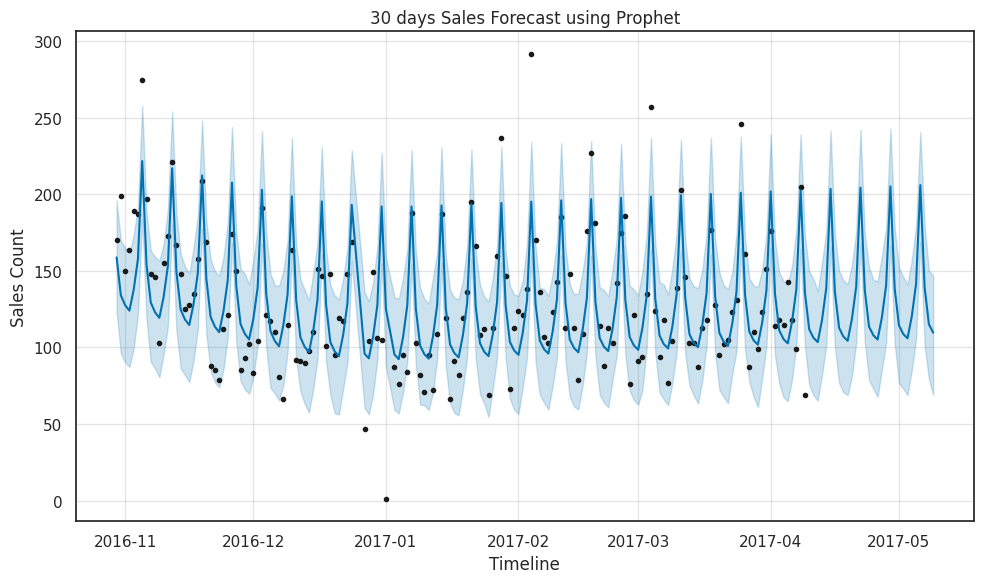

In [ ]:
model.plot(forecast)
plt.title("30 days Sales Forecast using Prophet")
plt.xlabel('Timeline')
plt.ylabel('Sales Count')
plt.tight_layout()
plt.show()

# model.plot_components(forecast)
# plt.title('Components of the 30-Day Sales Forecast')
# plt.tight_layout()
# plt.show()

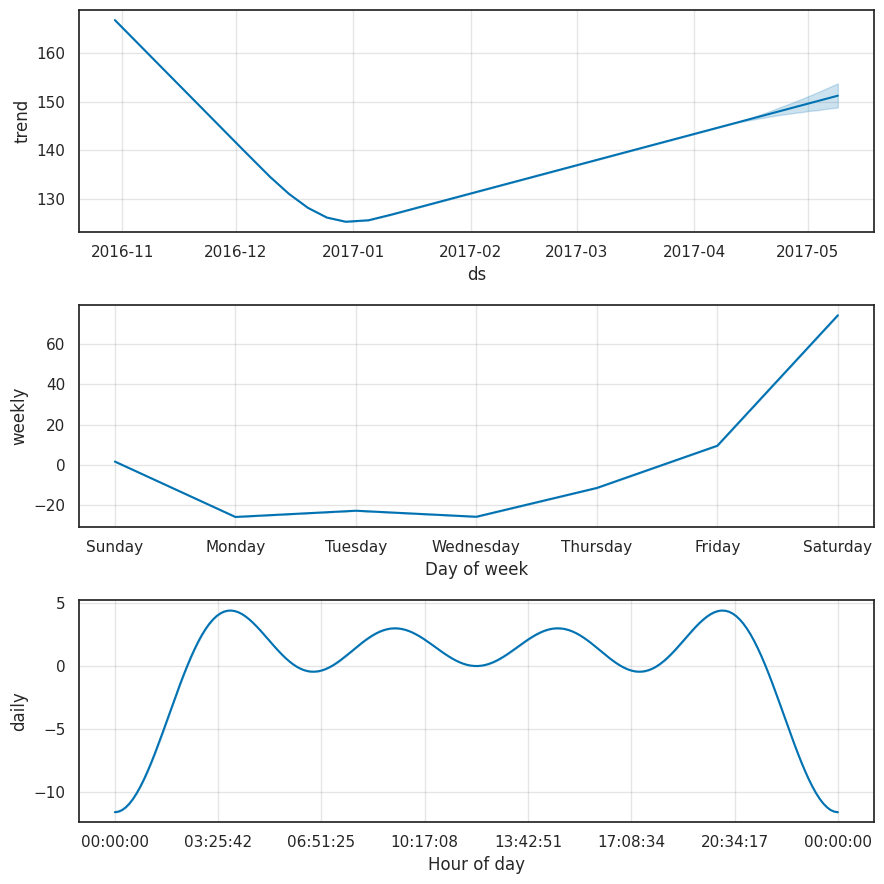

In [ ]:
model.plot_components(forecast)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

# Step 1: Copy and reset index
df = daily_sales.copy().reset_index()
df.columns = ['date', 'sales']

# Step 2: Extract time-based features
df['day'] = df['date'].dt.day
df['month'] = df['date'].dt.month
df['dayofweek'] = df['date'].dt.dayofweek  # 0 = Monday
df['weekofyear'] = df['date'].dt.isocalendar().week.astype(int)
df['is_weekend'] = df['dayofweek'].apply(lambda x: 1 if x > 5 else 0)
df['month_start'] = df['date'].dt.is_month_start.astype(int)
df['month_end'] = df['date'].dt.is_month_end.astype(int)
df['is_christmas_week'] = df['date'].apply(lambda x: 1 if x.strftime('%m-%d') in ['12-24', '12-25', '12-26'] else 0)

In [ ]:
df

,date,sales,day,month,dayofweek,weekofyear,is_weekend,month_start,month_end,is_christmas_week
0,2016-10-30,170,30,10,6,43,1,0,0,0
1,2016-10-31,199,31,10,0,44,0,0,1,0
2,2016-11-01,150,1,11,1,44,0,1,0,0
3,2016-11-02,164,2,11,2,44,0,0,0,0
4,2016-11-03,189,3,11,3,44,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...
157,2017-04-05,143,5,4,2,14,0,0,0,0
158,2017-04-06,118,6,4,3,14,0,0,0,0
159,2017-04-07,99,7,4,4,14,0,0,0,0
160,2017-04-08,205,8,4,5,14,0,0,0,0


In [ ]:
# Train = all but last 30 days
train = df.iloc[:-30]
test = df.iloc[-30:]

# Features and target
features = ['day', 'month', 'dayofweek', 'weekofyear', 'is_weekend']

X_train = train[features]
y_train = train['sales']

X_test = test[features]
y_test = test['sales']

RMSE: 26.104894467067258
R2 Score: 0.552314043045044


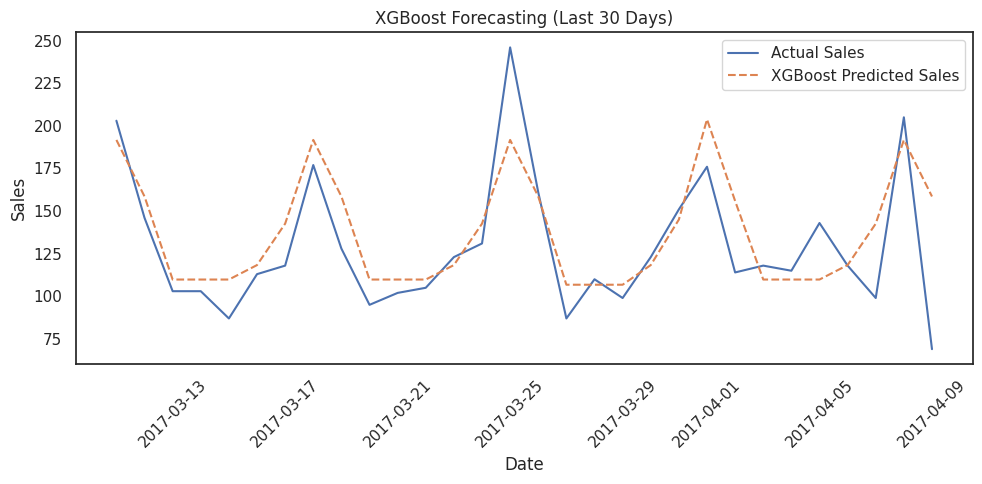

In [ ]:
from xgboost import XGBRegressor

model = XGBRegressor(n_estimators=50, learning_rate=0.05,max_depth=3)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))

plt.figure(figsize=(10,5))
plt.plot(test['date'], y_test.values, label='Actual Sales')
plt.plot(test['date'], y_pred, label='XGBoost Predicted Sales', linestyle='--')
plt.title('XGBoost Forecasting (Last 30 Days)')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Combine all item names into one string
text = (' ').join(my_List)

# Generate word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

# Plot it
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Top Items Ordered by Customers', fontsize=16)
plt.tight_layout()
plt.show()

NameError: name 'my_List' is not defined

In [ ]:
my_List=[]
for i in revised_df['Item_clean']:
    my_List.append(i)

In [ ]:
revised_df['Item'].value_counts()

In [ ]:
revised_df

In [ ]:
sns.boxplot(x='day_name', y='Basket', data=df_grouped)
plt.title('Basket Size Distribution: Weekday vs Weekend')
plt.xlabel('Day of Week')
plt.xticks(rotation=65)
plt.ylabel('Basket Size')
plt.show()

ValueError: Could not interpret value `Basket` for `y`. An entry with this name does not appear in `data`.

In [ ]:
plt.figure(figsize=(10, 8))
sns.boxplot(y='day_name', x='Basket', data=df_grouped, color='skyblue')
plt.title('Distribution of Hourly Transactions Across Days (Horizontal)')
plt.xlabel('Transaction Count per Hour')
plt.ylabel('Hour of the Day')
plt.tight_layout()
plt.show()

ValueError: Could not interpret value `Basket` for `x`. An entry with this name does not appear in `data`.

<Figure size 1000x800 with 0 Axes>

In [ ]:
df_grouped

,Transaction,Item,Day,day_name,period_day,Year,Month
0,1,[Bread],30,Sunday,morning,2016,October
1,2,"[Scandinavian, Scandinavian]",30,Sunday,morning,2016,October
2,3,"[Hot chocolate, Jam, Cookies]",30,Sunday,morning,2016,October
3,4,[Muffin],30,Sunday,morning,2016,October
4,5,"[Coffee, Pastry, Bread]",30,Sunday,morning,2016,October
...,...,...,...,...,...,...,...
9460,9680,[Bread],9,Sunday,afternoon,2017,April
9461,9681,"[Truffles, Tea, Spanish Brunch, Christmas common]",9,Sunday,afternoon,2017,April
9462,9682,"[Muffin, Tacos-Fajita, Coffee, Tea]",9,Sunday,afternoon,2017,April
9463,9683,"[Coffee, Pastry]",9,Sunday,afternoon,2017,April


In [ ]:
df_grouped['Basket']=df_grouped['Item'].apply(lambda x: len(x))

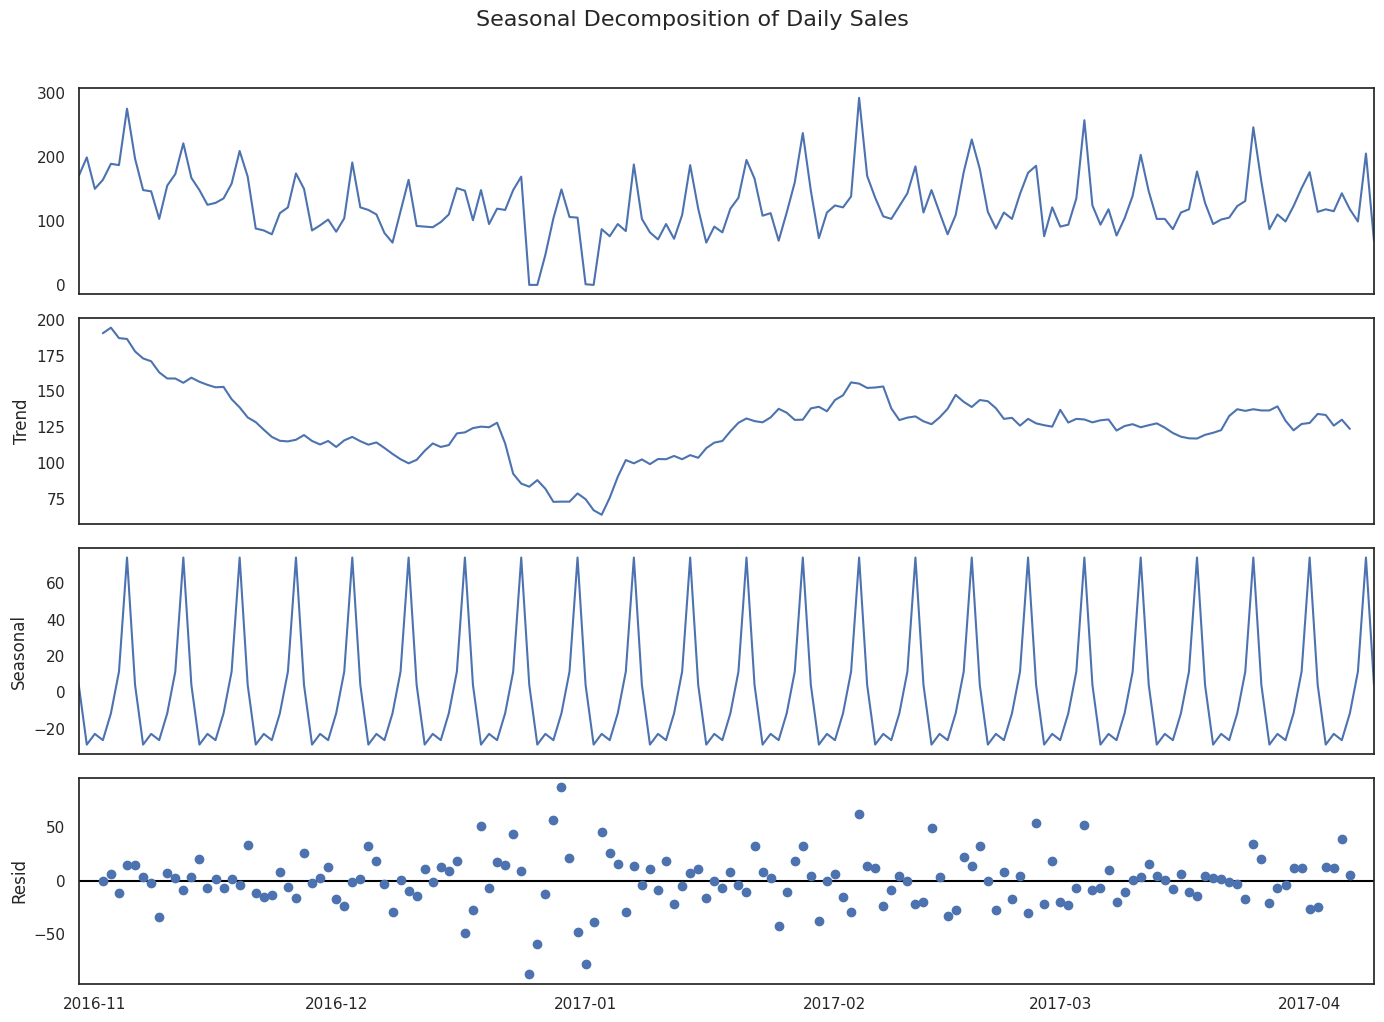

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Perform seasonal decomposition (weekly seasonality assumed)
result = seasonal_decompose(daily_sales, model='additive', period=7)

# Plot with improved size and layout
fig = result.plot()
fig.set_size_inches(14, 10)  # Bigger and clearer
plt.suptitle('Seasonal Decomposition of Daily Sales', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

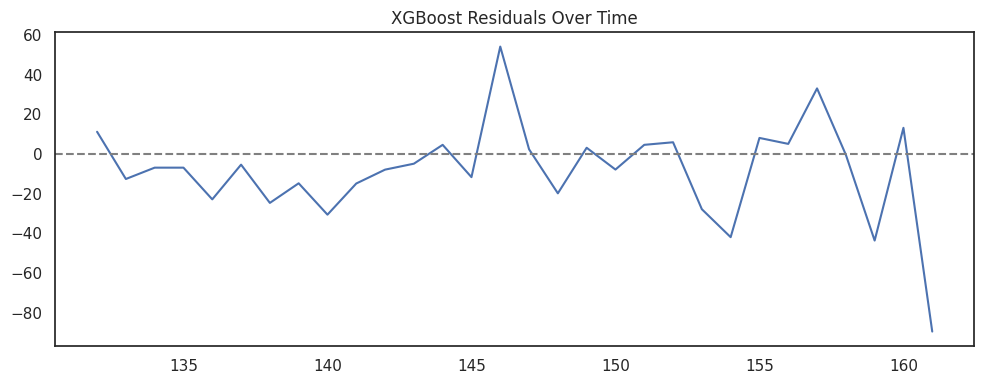

In [ ]:
residuals = y_test - y_pred
plt.figure(figsize=(10, 4))
plt.plot(residuals)
plt.title("XGBoost Residuals Over Time")
plt.axhline(0, linestyle='--', color='gray')
plt.tight_layout()
plt.show()